# Part 3 – Commercial performance dashboard
Armani Middle East Trading technical assessment · **Part 3: interactive dashboard (Streamlit)**

This notebook builds, tests and documents the dashboard: it builds the KPI data mart (`dashboard_data.db`) from Parts 1–2, **generates the app** (`dashboard_app.py`), tests the KPI logic, and screenshots every tab.

**Tabs:** Overview · Financial · Stock & service · Customer credit (scenario) · Forecast · Pricing · Alerts · Notes. Every tab opens with a one-sentence bottom line for non-technical readers. The Pricing tab is filled by `part4_pricing.ipynb`, which adds its tables to this database.

| KPI layer | KPIs | Basis |
|---|---|---|
| **Data-driven** | revenue, gross margin, operating profit, growth, stock turnover, days of stock (DSI), service level, lost revenue, forecast, stock / margin / revenue alerts | computed from the data |
| **Scenario (assumptions)** | **DSO, default-risk rating**, credit alerts | the dataset has no customers, invoices or payment terms: driven by editable assumptions, labelled as such everywhere |

In [1]:
import importlib.util
import json
import socket
import subprocess
import sys
import time
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import sqlite3

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
HERE = Path.cwd()
ETL_DB = HERE / "results" / "part1_step2_etl_pipeline" / "armani_trade.db"
PRE_DB = HERE / "results" / "part2_step1_preprocessing" / "forecast_dataset.db"
FC_DB = HERE / "results" / "part2_step2_forecasting" / "forecast_results.db"
APP_DIR = HERE / "part3_dashboard"            # deployable app (committed)
APP_DIR.mkdir(parents=True, exist_ok=True)
OUT = HERE / "results" / "part3_dashboard"        # generated results (workbook, screenshots)
OUT.mkdir(parents=True, exist_ok=True)
SHOTS = OUT / "screenshots"
SHOTS.mkdir(exist_ok=True)
DATA_DB = APP_DIR / f"dashboard_data.db"
APP_PATH = APP_DIR / f"dashboard_app.py"
XLSX_PATH = OUT / f"dashboard_results.xlsx"

## 1. Build the KPI data mart
One row per product-week (`hist`: revenue, COGS, profits, stock available, estimated demand, lost demand), the 26-week forecast (`fcst`), the product list, the credit-scenario defaults and model metadata.

In [2]:
for p in (ETL_DB, PRE_DB, FC_DB):
    if not p.exists():
        raise FileNotFoundError(f"{p} not found - run the earlier notebooks first")

def read(db, sql):
    con = sqlite3.connect(db)
    try:
        return pd.read_sql(sql, con)
    finally:
        con.close()

etl = read(ETL_DB, "SELECT * FROM vw_sales_enriched")
pre = read(PRE_DB, "SELECT product_id, week_id, demand_est, demand_source, censor_status, stock_regime FROM demand_panel")
fc = read(FC_DB, "SELECT * FROM fact_demand_forecast")
comp = read(FC_DB, "SELECT * FROM model_comparison")
run_info = read(FC_DB, "SELECT * FROM run_info")

hist = etl.merge(pre, on=["product_id", "week_id"], how="left", validate="1:1")
assert hist.demand_est.notna().all() and len(hist) == 7800

hist = hist.rename(columns={"product_category": "category", "inventory_profile": "segment", "sales_units": "units", "week_start_date": "week_start"})
hist["cogs"] = hist.units * hist.unit_cogs
hist["opex_implied"] = hist.gross_profit - hist.operating_profit
hist["stock_units"] = hist.stock_available_for_sales
hist["stock_value"] = hist.stock_units * hist.unit_cogs
hist["lost_units"] = (hist.demand_est - hist.units).clip(lower=0)
hist["lost_revenue"] = hist.lost_units * hist.unit_price
hist["lost_gp"] = hist.lost_units * (hist.unit_price - hist.unit_cogs)
hist["ym"] = hist.week_start.str[:7]
hist["year_index"] = (hist.week_id - 1) // 52 + 1
HIST_COLS = ["product_id", "product_name", "category", "segment", "stock_regime", "week_id", "week_start", "ym", "year", "quarter", "month", "year_index",
             "units", "demand_est", "unit_price", "unit_cogs", "revenue", "cogs", "gross_profit", "operating_profit", "opex_implied",
             "inventory_level", "stock_units", "stock_value", "censor_status", "lost_units", "lost_revenue", "lost_gp"]
hist = hist[HIST_COLS].sort_values(["product_id", "week_id"]).reset_index(drop=True)

prods = hist.drop_duplicates("product_id")[["product_id", "product_name", "category", "segment", "stock_regime"]].reset_index(drop=True)
fc = fc.merge(prods[["product_id", "category", "stock_regime"]], on="product_id", how="left")
fc = fc.rename(columns={"demand_forecast_p50": "demand_forecast", "demand_p10": "p10", "demand_p90": "p90", "week_start_date": "week_start",
                        "last13_price": "price", "last13_cogs": "cogs_unit", "expected_revenue": "exp_revenue", "expected_gross_profit": "exp_gp",
                        "expected_sales_hist_stock": "exp_sales_units", "expected_sales_revenue": "exp_sales_revenue",
                        "prob_stock_below_demand": "prob_stock_below", "expected_lost_units": "exp_lost_units"})
fc["exp_lost_revenue"] = fc.exp_lost_units * fc.price
fc["ym"] = fc.week_start.str[:7]
FC_COLS = ["product_id", "product_name", "category", "segment", "stock_regime", "week_id", "week_start", "ym", "h", "demand_forecast", "p10", "p90", "price", "cogs_unit",
           "exp_revenue", "exp_gp", "exp_sales_units", "exp_sales_revenue", "prob_stock_below", "exp_lost_units", "exp_lost_revenue"]
fc = fc[FC_COLS]
assert len(fc) == 780 and fc.week_id.min() == 261

# ASSUMPTIONS (illustrative, editable in the app): the data has no customers / invoices / payment terms
credit = pd.DataFrame({
    "category": ["Beverages & Cocoa", "Canned Foods", "Cereals & Grains", "Dairy", "Oils & Fats", "Pulses", "Spices & Seasonings", "Sugar"],
    "terms_days": [60, 45, 45, 30, 30, 45, 60, 30],
    "credit_share_pct": [75, 65, 70, 55, 60, 65, 70, 60],
    "avg_delay_days": [12, 7, 6, 4, 4, 6, 10, 5],
    "annual_default_rate_pct": [1.8, 1.1, 1.0, 0.8, 0.8, 1.0, 1.5, 0.9],
})
assert set(credit.category) == set(prods.category)

best = comp.sort_values("WAPE").iloc[0]
meta = {
    "selected_model": str(run_info.selected_label[0]), "wape": float(best.WAPE), "wape_truth": float(best.WAPE_truth_cells), "mase": float(best.MASE),
    "mape": float(best["MAPE_%"]), "n_models": int(len(comp)), "horizon_weeks": int(run_info.horizon_weeks[0]),
    "last_week_id": int(hist.week_id.max()), "last_week_start": str(hist.week_start.max()), "first_week_start": str(hist.week_start.min()),
    "forecast_first_week": str(fc.week_start.min()), "forecast_last_week": str(fc.week_start.max()),
    "hist_demand_unserved_pct": float(100 * hist.lost_units.sum() / hist.demand_est.sum()),
}
meta = pd.DataFrame({"key": list(meta), "value": [str(v) for v in meta.values()]})

if DATA_DB.exists():
    DATA_DB.unlink()
con = sqlite3.connect(DATA_DB)
with con:
    hist.to_sql("hist", con, index=False); fc.to_sql("fcst", con, index=False); prods.to_sql("products", con, index=False)
    credit.to_sql("credit_defaults", con, index=False); meta.to_sql("meta", con, index=False)
    con.execute("CREATE INDEX idx_hist_pw ON hist (product_id, week_id)")
con.close()
print("written", DATA_DB.name, round(DATA_DB.stat().st_size / 1e6, 2), "MB | hist", hist.shape, "fcst", fc.shape)
hist.head(3)

written dashboard_data.db 1.69 MB | hist (7800, 28) fcst (780, 21)


,product_id,product_name,category,segment,stock_regime,week_id,week_start,ym,year,quarter,month,year_index,units,demand_est,unit_price,unit_cogs,revenue,cogs,gross_profit,operating_profit,opex_implied,inventory_level,stock_units,stock_value,censor_status,lost_units,lost_revenue,lost_gp
0,1,Barley,Cereals & Grains,normal,R2,1,2020-01-06,2020-01,2020,1,1,1,2669,2669.00,8.03,5.98,21432.07,15960.62,5471.45,3754.78,1716.67,2500,NaN,NaN,stock_unknown,0.00,0.0000,0.0000
1,1,Barley,Cereals & Grains,normal,R2,2,2020-01-13,2020-01,2020,1,1,1,2500,2658.95,7.82,6.00,19550.00,15000.00,4550.00,2750.07,1799.93,1500,2500.0,15000.0,stock_limited,158.95,1242.9890,289.2890
2,1,Barley,Cereals & Grains,normal,R2,3,2020-01-20,2020-01,2020,1,1,1,1500,2610.91,6.98,5.70,10470.00,8550.00,1920.00,682.01,1237.99,0,1500.0,8550.0,stock_limited,1110.91,7754.1518,1421.9648


### Credit scenario assumptions (editable in the app)
Illustrative values typical of B2B food trading – **assumptions, not derived from the data**.

In [3]:
credit

,category,terms_days,credit_share_pct,avg_delay_days,annual_default_rate_pct
0,Beverages & Cocoa,60,75,12,1.8
1,Canned Foods,45,65,7,1.1
2,Cereals & Grains,45,70,6,1.0
3,Dairy,30,55,4,0.8
4,Oils & Fats,30,60,4,0.8
5,Pulses,45,65,6,1.0
6,Spices & Seasonings,60,70,10,1.5
7,Sugar,30,60,5,0.9


## 2. KPI definitions

In [4]:
KPI_DEFS = pd.DataFrame([
    ("Revenue", "Financial", "Σ units sold × price (verified against the source for 100% of rows in the ETL)", "data"),
    ("Gross profit margin", "Financial", "Σ gross profit / Σ revenue (ratio of sums, not mean of ratios)", "data"),
    ("Operating profit (and margin)", "Financial", "Operating profit as given in the data; opex is not provided → implied opex = gross profit − operating profit", "data"),
    ("Revenue growth", "Financial", "Revenue of the selected weeks vs the same weeks 52 weeks earlier", "data"),
    ("Inventory turnover", "Operational", "Annualised COGS / average inventory at cost; inventory = stock available during each week (previous row's inventory)", "data"),
    ("Days sales of inventory (DSI)", "Operational", "Average inventory at cost / COGS per day", "data"),
    ("Weeks of cover", "Operational", "Average stock units / average weekly reconstructed demand", "data"),
    ("Service level (fill rate)", "Operational", "Units sold / reconstructed demand", "data"),
    ("Lost revenue", "Operational", "Σ max(demand − sales, 0) × price: demand not served because of stock-outs / stock caps", "data"),
    ("DSO", "Sales & credit", "credit share × (payment terms + average delay), revenue-weighted over categories", "SCENARIO (assumptions)"),
    ("Receivables", "Sales & credit", "daily revenue × DSO per category", "SCENARIO (assumptions)"),
    ("Expected credit loss", "Sales & credit", "credit share × annual default rate × annualised revenue", "SCENARIO (assumptions)"),
    ("Customer default risk rating", "Sales & credit", "A–E from risk score = 40% default rate + 20% lateness + 25% loss vs gross profit + 15% revenue concentration (see app)", "SCENARIO (assumptions)"),
], columns=["KPI", "Domain", "Definition", "Basis"])
KPI_DEFS

,KPI,Domain,Definition,Basis
0,Revenue,Financial,Σ units sold × price (verified against the sou...,data
1,Gross profit margin,Financial,"Σ gross profit / Σ revenue (ratio of sums, not...",data
2,Operating profit (and margin),Financial,Operating profit as given in the data; opex is...,data
3,Revenue growth,Financial,Revenue of the selected weeks vs the same week...,data
4,Inventory turnover,Operational,Annualised COGS / average inventory at cost; i...,data
5,Days sales of inventory (DSI),Operational,Average inventory at cost / COGS per day,data
6,Weeks of cover,Operational,Average stock units / average weekly reconstru...,data
7,Service level (fill rate),Operational,Units sold / reconstructed demand,data
8,Lost revenue,Operational,"Σ max(demand − sales, 0) × price: demand not s...",data
9,DSO,Sales & credit,credit share × (payment terms + average delay)...,SCENARIO (assumptions)


## 3. Generate the Streamlit app
Written to `dashboard_app.py`; it reads `dashboard_data.db` from its own folder, so the folder can be deployed as is. KPI, alert and credit logic are plain functions at the top of the file, which the tests below import.

In [5]:
APP_SRC = r'''"""Armani Middle East Trading - commercial KPI dashboard (Streamlit).

Generated by part3_dashboard.ipynb. Reads dashboard_data.db (same folder).
Run:  streamlit run dashboard_app.py
"""
from __future__ import annotations

import re
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import streamlit as st
DB_PATH = Path(__file__).parent / f"dashboard_data.db"
WEEKS_PER_YEAR = 52
PRICING_TABLES = ["price_plan", "pricing_products", "pricing_scenarios", "pricing_actions", "pricing_meta"]

# validated categorical palette (blue / orange / aqua), neutrals and status colours
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
BLUE_LIGHT, AQUA_LIGHT = "#9ec5f4", "#bfe9d9"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1", "#fcfcfb"
STATUS_COLOR = {"High": "#d03b3b", "Medium": "#ec835a", "Low": "#fab219"}
STATUS_ICON = {"High": "▲ High", "Medium": "◆ Medium", "Low": "● Low"}
RATING_COLOR = {"A": "#0ca30c", "B": "#7fb800", "C": "#fab219", "D": "#ec835a", "E": "#d03b3b"}

DEFAULT_THRESHOLDS = {
    "cover_max": 26.0,        # overstock: weeks of stock above this
    "lost_share_max": 20.0,   # stock-out risk: % of forecast revenue not served
    "rev_decline_pct": 10.0,  # revenue decline vs same weeks last year (26 weeks)
    "margin_drop_pp": 1.0,    # gross margin drop in percentage points (13 vs previous 52 weeks)
    "ecl_gp_max": 6.0,        # credit: expected credit loss as % of gross profit
    "dso_max": 55.0,          # credit: DSO in days
    "peak_uplift_pct": 25.0,  # seasonal peak: forecast peak vs last 13 weeks
}

# ----------------------------------------------------------------------------- data
@st.cache_data(show_spinner=False)
def load_data() -> dict:
    con = sqlite3.connect(DB_PATH)
    have = {r[0] for r in con.execute("SELECT name FROM sqlite_master WHERE type = 'table'")}
    d = {t: pd.read_sql(f"SELECT * FROM {t}", con) for t in ["hist", "fcst", "products", "credit_defaults", "meta"]}
    d.update({t: pd.read_sql(f"SELECT * FROM {t}", con) for t in PRICING_TABLES if t in have})     # added by part4_pricing.ipynb
    con.close()
    for t in ("hist", "fcst"):
        d[t]["week_start"] = pd.to_datetime(d[t]["week_start"])
        yi = (d[t].week_id - 1) // 52 + 1
        q = ((d[t].week_id - 1) % 52) // 13 + 1
        d[t]["pq"] = "Y" + yi.astype(str) + "-Q" + q.astype(str)
    d["meta"] = dict(zip(d["meta"].key, d["meta"].value))
    return d


# ----------------------------------------------------------------------------- formatting
def money(x: float, dec: int = 1) -> str:
    if x is None or not np.isfinite(x):
        return "n/a"
    a = abs(x)
    s = f"{a / 1e9:.{dec}f}B" if a >= 1e9 else f"{a / 1e6:.{dec}f}M" if a >= 1e6 else f"{a / 1e3:.0f}K" if a >= 1e4 else f"{a:,.0f}"
    return ("-" if x < 0 else "") + "$" + s


def pct(x: float, dec: int = 1) -> str:
    return "n/a" if x is None or not np.isfinite(x) else f"{100 * x:.{dec}f}%"


def num(x: float, dec: int = 0) -> str:
    return "n/a" if x is None or not np.isfinite(x) else f"{x:,.{dec}f}"


# ----------------------------------------------------------------------------- KPI logic (pure functions, unit-tested in the notebook)
def kpis(h: pd.DataFrame, a: int, b: int) -> dict:
    """KPIs for weeks a..b (inclusive) of the (already filtered) history frame."""
    s = h[(h.week_id >= a) & (h.week_id <= b)]
    weeks = b - a + 1
    rev, gp, op, cogs, units = s.revenue.sum(), s.gross_profit.sum(), s.operating_profit.sum(), s.cogs.sum(), s.units.sum()
    stock_v = s.groupby("week_id").stock_value.sum(min_count=1).dropna()
    stock_u = s.groupby("week_id").stock_units.sum(min_count=1).dropna()
    avg_stock = stock_v.mean() if len(stock_v) else np.nan
    dem = s.demand_est.sum()
    return {
        "weeks": weeks, "revenue": rev, "gross_profit": gp, "operating_profit": op, "cogs": cogs, "units": units, "demand": dem,
        "gpm": gp / rev if rev else np.nan, "opm": op / rev if rev else np.nan, "opex": gp - op,
        "avg_stock_value": avg_stock,
        "turnover": (cogs * WEEKS_PER_YEAR / weeks) / avg_stock if avg_stock and avg_stock > 0 else np.nan,
        "dsi": avg_stock / (cogs / (weeks * 7)) if cogs > 0 and avg_stock == avg_stock else np.nan,
        "weeks_cover": (stock_u.mean() / (dem / weeks)) if len(stock_u) and dem > 0 else np.nan,
        "service_level": units / dem if dem else np.nan,
        "lost_revenue": s.lost_revenue.sum(), "lost_units": s.lost_units.sum(),
        "lost_share": s.lost_revenue.sum() / (rev + s.lost_revenue.sum()) if rev else np.nan,
    }


def growth_yoy(h: pd.DataFrame, a: int, b: int) -> float:
    """Revenue growth of weeks a..b versus the same weeks 52 weeks earlier."""
    if a - WEEKS_PER_YEAR < 1:
        return np.nan
    cur = h[(h.week_id >= a) & (h.week_id <= b)].revenue.sum()
    prev = h[(h.week_id >= a - WEEKS_PER_YEAR) & (h.week_id <= b - WEEKS_PER_YEAR)].revenue.sum()
    return cur / prev - 1 if prev else np.nan


def credit_table(h: pd.DataFrame, a: int, b: int, cred: pd.DataFrame) -> pd.DataFrame:
    """ASSUMPTION-BASED credit scenario: DSO, receivables, expected loss and a transparent A-E rating per category."""
    s = h[(h.week_id >= a) & (h.week_id <= b)]
    weeks = b - a + 1
    g = s.groupby("category").agg(revenue=("revenue", "sum"), gross_profit=("gross_profit", "sum")).reset_index()
    g = g.merge(cred, on="category", how="left")
    share, dflt = g.credit_share_pct / 100, g.annual_default_rate_pct / 100
    g["dso"] = share * (g.terms_days + g.avg_delay_days)
    g["receivables"] = g.revenue / (weeks * 7) * g.dso
    g["ecl_annual"] = share * dflt * g.revenue * WEEKS_PER_YEAR / weeks
    g["ecl_pct_gp"] = g.ecl_annual / (g.gross_profit * WEEKS_PER_YEAR / weeks).replace(0, np.nan)
    g["rev_share"] = g.revenue / g.revenue.sum()
    g["s_default"] = np.minimum(dflt / 0.03, 1) * 100
    g["s_late"] = np.minimum(g.avg_delay_days / g.terms_days / 0.5, 1) * 100
    g["s_buffer"] = np.minimum(g.ecl_pct_gp / 0.15, 1) * 100
    g["s_conc"] = np.minimum(g.rev_share / 0.25, 1) * 100
    g["risk_score"] = 0.40 * g.s_default + 0.20 * g.s_late + 0.25 * g.s_buffer + 0.15 * g.s_conc
    g["rating"] = pd.cut(g.risk_score, [-1, 20, 35, 50, 65, 1000], labels=list("ABCDE"), right=False).astype(str)
    return g


def compute_alerts(d: dict, cred: pd.DataFrame, thr: dict) -> pd.DataFrame:
    """Rule-based alerts (company-wide, independent of the sidebar filters). $ at stake is in the units named in 'at_stake_basis'."""
    h, f, prods = d["hist"], d["fcst"], d["products"]
    last = int(h.week_id.max())
    rows = []

    def add(sev, typ, scope, name, metric, value, threshold, stake, basis, action, kind="data"):
        rows.append(dict(severity=sev, type=typ, scope=scope, name=name, metric=metric, value=value, threshold=threshold,
                         at_stake=stake, at_stake_basis=basis, action=action, kind=kind))

    cur13 = h[h.week_id > last - 13]
    cur26 = h[h.week_id > last - 26]
    for pid, g in cur13.groupby("product_id"):
        name = g.product_name.iloc[0]
        dem_w, stock_w = g.demand_est.mean(), g.stock_units.mean()
        cover = stock_w / dem_w if dem_w else np.nan
        if cover == cover and cover > thr["cover_max"]:
            excess = (stock_w - thr["cover_max"] * dem_w)
            add("High" if cover > 4 * thr["cover_max"] else "Medium", "Overstock", "Product", name, "weeks of stock", cover, thr["cover_max"],
                excess * g.unit_cogs.iloc[-1], "capital tied up (at cost)",
                f"Pause purchasing for ~{(stock_w - thr['cover_max'] * dem_w) / dem_w:,.0f} weeks; excess stock ~{excess:,.0f} units - promote or liquidate.")
    for pid, g in f.groupby("product_id"):
        rev, lost = g.exp_revenue.sum(), g.exp_lost_revenue.sum()
        share = lost / rev if rev else 0
        if share * 100 > thr["lost_share_max"]:
            hs = h[(h.product_id == pid) & (h.week_id > last - 52)]
            p90_peak = g.sort_values("h").head(8).p90.max()
            add("High" if share > 0.5 else "Medium", "Stock-out risk", "Product", g.product_name.iloc[0], "% of forecast demand revenue not served", 100 * share,
                thr["lost_share_max"], lost, "revenue at risk (next 26 weeks)",
                f"Raise stock cover: plan for >= {p90_peak:,.0f} units/week in the next 8 weeks (P90); typical stock last year {hs.stock_units.median():,.0f} units.")
    prev26 = h[(h.week_id <= last - 26) & (h.week_id > last - 78)]
    for pid, g in cur26.groupby("product_id"):
        year_ago = h[(h.product_id == pid) & (h.week_id > last - 26 - 52) & (h.week_id <= last - 52)].revenue.sum()
        if year_ago > 0:
            ch = g.revenue.sum() / year_ago - 1
            if ch * 100 < -thr["rev_decline_pct"]:
                add("Medium", "Revenue decline", "Product", g.product_name.iloc[0], "revenue vs same weeks last year (%)", 100 * ch, -thr["rev_decline_pct"],
                    year_ago - g.revenue.sum(), "revenue shortfall (26 weeks)", "Check stock availability and demand drivers for this product.")
    base = h[(h.week_id <= last - 13) & (h.week_id > last - 65)]
    for pid, g in cur13.groupby("product_id"):
        b = base[base.product_id == pid]
        if len(b) and g.revenue.sum() > 0 and b.revenue.sum() > 0:
            drop = 100 * (b.gross_profit.sum() / b.revenue.sum() - g.gross_profit.sum() / g.revenue.sum())
            if drop > thr["margin_drop_pp"]:
                add("Medium", "Margin erosion", "Product", g.product_name.iloc[0], "gross margin drop (pp)", drop, thr["margin_drop_pp"],
                    g.revenue.sum() * drop / 100, "gross profit lost (13 weeks)", "Review price vs landed cost; COGS increased faster than price.")
    ct = credit_table(h, last - 51, last, cred)
    for r in ct.itertuples():
        if r.ecl_pct_gp * 100 > thr["ecl_gp_max"] or r.dso > thr["dso_max"]:
            sev = "High" if r.rating in ("D", "E") else "Medium"
            add(sev, "Credit exposure (scenario)", "Category", r.category, f"DSO {r.dso:.0f} d | expected loss {100 * r.ecl_pct_gp:.1f}% of GP",
                r.ecl_pct_gp * 100, thr["ecl_gp_max"], r.ecl_annual, "expected credit loss / year", "Tighten terms, require credit insurance, focus collections.", kind="scenario")
    fw = f.groupby("week_id").agg(p50=("demand_forecast", "sum"))
    recent = cur13.groupby("week_id").demand_est.sum().mean()
    pk = fw.p50.max() / recent - 1
    if pk * 100 > thr["peak_uplift_pct"]:
        add("Low", "Seasonal peak ahead", "Company", "All products", "forecast peak vs last 13 weeks (%)", 100 * pk, thr["peak_uplift_pct"], 0.0, "-",
            f"Demand peaks in week {int(fw.p50.idxmax())} (+{100 * pk:.0f}% vs recent weeks): pre-build stock and confirm logistics capacity.")
    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(columns=["severity", "type", "scope", "name", "metric", "value", "threshold", "at_stake", "at_stake_basis", "action", "kind"])
    out["_o"] = out.severity.map({"High": 0, "Medium": 1, "Low": 2})
    return out.sort_values(["_o", "at_stake"], ascending=[True, False]).drop(columns="_o").reset_index(drop=True)


# ----------------------------------------------------------------------------- chart helpers
def style(fig: go.Figure, height: int = 360, title: str | None = None, legend: bool = True) -> go.Figure:
    fig.update_layout(
        height=height, margin=dict(l=8, r=8, t=36 if legend else 8, b=8), paper_bgcolor=SURFACE, plot_bgcolor=SURFACE, meta=title,
        font=dict(color=INK2, size=12),
        legend=dict(orientation="h", y=1.0, yanchor="bottom", x=0, bgcolor="rgba(0,0,0,0)") if legend else dict(visible=False), hovermode="x unified")
    fig.update_xaxes(showgrid=False, linecolor=GRID, zeroline=False)
    fig.update_yaxes(gridcolor=GRID, zeroline=False)
    return fig


def show(fig: go.Figure, key: str) -> None:
    if fig.layout.meta:
        st.markdown(f"**{fig.layout.meta}**")
    st.plotly_chart(fig, width="stretch", key=key, config={"displaylogo": False})


def headline(text: str) -> None:
    """One plain-language sentence at the top of every tab: what a manager should take away."""
    text = re.sub(r"\*\*(.+?)\*\*", r"<b>\1</b>", text)
    st.markdown(f"<div style='background:rgba(42,120,214,0.10);border-left:4px solid {BLUE};padding:10px 14px;border-radius:4px;margin:2px 0 14px 0;font-size:1.02rem'>{text}</div>",
                unsafe_allow_html=True)


def sev_html(sev: str) -> str:
    return f"<span style='color:{STATUS_COLOR[sev]};font-weight:600'>{STATUS_ICON[sev]}</span>"


# ----------------------------------------------------------------------------- UI pieces
def alerts_table(al: pd.DataFrame, n: int | None = None, key: str = "al", compact: bool = False) -> None:
    if al.empty:
        st.success("No alerts at the current thresholds.")
        return
    t = al.head(n) if n else al
    t = t.assign(severity=t.severity.map(STATUS_ICON), kind=t.kind.map({"data": "data", "scenario": "scenario (assumptions)"}))
    cols = ["severity", "type", "name", "at_stake"] if compact else ["severity", "type", "name", "value", "threshold", "at_stake", "at_stake_basis", "action"]
    st.dataframe(t[cols], hide_index=True, width="stretch", key=key,
                 column_config={"severity": "Severity", "type": "Alert", "name": "Where", "metric": "Metric", "value": st.column_config.NumberColumn("Value", format="%.1f"),
                                "threshold": st.column_config.NumberColumn("Threshold", format="%.1f"),
                                "at_stake": st.column_config.NumberColumn("$ at stake", format="compact"), "at_stake_basis": "Basis",
                                "action": st.column_config.TextColumn("Recommended action", width="large"), "kind": "Source"})


def kpi_cards(k: dict, kp: dict | None, g: float, ct: pd.DataFrame, a: int, b: int) -> None:
    def d_pp(x, y):
        return None if kp is None or not (np.isfinite(x) and np.isfinite(y)) else f"{100 * (x - y):+.1f} pp"

    def d_rel(x, y):
        return None if kp is None or not (np.isfinite(x) and np.isfinite(y) and y) else f"{100 * (x / y - 1):+.1f}%"

    c = st.columns(4)
    c[0].metric("Revenue", money(k["revenue"]), None if g != g else f"{100 * g:+.1f}% vs last year", help="Sum of weekly sales x price in the selected period. Delta = same weeks one year earlier.")
    c[1].metric("Gross profit margin", pct(k["gpm"]), d_pp(k["gpm"], kp["gpm"]) if kp else None, help="Gross profit / revenue (sums, not averages of ratios).")
    c[2].metric("Operating profit", money(k["operating_profit"]), d_rel(k["operating_profit"], kp["operating_profit"]) if kp else None,
                help=f"Operating margin {pct(k['opm'])}. Operating expenses are not in the data; implied opex = gross profit - operating profit = {money(k['opex'])}.")
    c[3].metric("Demand served (service level)", pct(k["service_level"]), d_pp(k["service_level"], kp["service_level"]) if kp else None,
                help="Units sold / reconstructed demand. The gap is demand lost to stock-outs and stock caps.")
    c = st.columns(4)
    c[0].metric("Stock turnover (times per year)", num(k["turnover"], 1), d_rel(k["turnover"], kp["turnover"]) if kp else None,
                help="Annualised COGS / average inventory at cost (stock available during each week).")
    c[1].metric("Days of stock (DSI)", f"{num(k['dsi'], 0)} days", d_rel(k["dsi"], kp["dsi"]) if kp else None, delta_color="inverse",
                help="Average inventory at cost / COGS per day. Lower is leaner.")
    dso = float((ct.dso * ct.revenue).sum() / ct.revenue.sum()) if len(ct) else np.nan
    c[2].metric("DSO - scenario", f"{num(dso, 0)} days", help="ASSUMPTION-BASED: the data has no receivables. DSO = credit share x (payment terms + average delay), revenue-weighted. Edit assumptions in the Sales & Credit tab.")
    worst = ct.sort_values("risk_score", ascending=False).head(1)
    c[3].metric("Default risk rating - scenario", worst.rating.iloc[0] if len(worst) else "n/a", f"worst: {worst.category.iloc[0]}" if len(worst) else None, delta_color="off",
                help="ASSUMPTION-BASED A-E rating (A lowest risk) from assumed default rate, lateness, loss vs margin and revenue concentration.")


# ----------------------------------------------------------------------------- tabs
def tab_exec(d, h, f, cred, a, b, label, al):
    k = kpis(h, a, b)
    kp = kpis(h, a - WEEKS_PER_YEAR, b - WEEKS_PER_YEAR) if a - WEEKS_PER_YEAR >= 1 else None
    ct = credit_table(h, a, b, cred)
    meta = d["meta"]
    last = int(meta["last_week_id"])
    ly_weeks = range(last - 52 + 1, last - 52 + 27)                       # same 26 weeks one year before the forecast
    fdem = f.demand_forecast.sum()
    ly_dem = h[h.week_id.isin(ly_weeks)].demand_est.sum()
    cur13 = d["hist"][d["hist"].week_id > last - 13]
    pc = cur13.groupby("product_name").agg(stock=("stock_units", "mean"), dem=("demand_est", "mean"), cogs=("unit_cogs", "last"))
    over = pc[pc.stock / pc.dem > DEFAULT_THRESHOLDS["cover_max"]]
    tied = ((over.stock - DEFAULT_THRESHOLDS["cover_max"] * over.dem) * over.cogs).sum()
    headline(f"**Bottom line:** margins are stable ({pct(k['gpm'])} gross), but **{pct(k['lost_share'])} of customer demand went unserved** because products ran out of stock "
             f"(about {money(k['lost_revenue'])} of sales), while {len(over)} products hold far more stock than they sell. The opportunity is availability and stock planning, not price cuts.")
    kpi_cards(k, kp, growth_yoy(h, a, b), ct, a, b)
    st.markdown("##### What the numbers say")
    st.markdown(
        f"- **Service level {pct(k['service_level'])}:** we served this share of what customers wanted in {label.lower()}.\n"
        f"- **{len(over)} products hold more than {DEFAULT_THRESHOLDS['cover_max']:.0f} weeks of stock**, tying up roughly **{money(tied)}** at cost, while the lean products run out.\n"
        f"- **Next 26 weeks:** demand is forecast at {num(fdem)} units ({('%+.1f%%' % (100 * (fdem / ly_dem - 1))) if ly_dem else 'n/a'} vs the same weeks last year); "
        f"at historical stock levels about **{pct(f.exp_lost_revenue.sum() / f.exp_revenue.sum())}** of it would again be unserved.")
    c1, c2 = st.columns(2)
    hq = h.groupby("pq").agg(revenue=("revenue", "sum"), ws=("week_start", "min")).reset_index().sort_values("ws")
    fq = f.groupby("pq").agg(exp_sales=("exp_sales_revenue", "sum"), pot=("exp_revenue", "sum"), ws=("week_start", "min")).reset_index().sort_values("ws")
    fig = go.Figure()
    fig.add_bar(x=hq.pq, y=hq.revenue, name="Actual revenue", marker_color=BLUE, hovertemplate="%{y:$,.0f}")
    fig.add_bar(x=fq.pq, y=fq.exp_sales, name="Forecast revenue (at historical stock)", marker_color=AQUA, hovertemplate="%{y:$,.0f}")
    fig.add_scatter(x=fq.pq, y=fq.pot, mode="markers", name="Demand potential if stock never ran out", marker=dict(color=ORANGE, size=10, line=dict(color=SURFACE, width=2)), hovertemplate="%{y:$,.0f}")
    fig.update_layout(barmode="group", bargap=0.25)
    fig.update_yaxes(tickprefix="$", tickformat="~s")
    with c1:
        show(style(fig, 360, "Revenue by 13-week quarter (Y = data year) and the 26-week forecast"), "exec_rev")
    with c2:
        st.markdown("##### Top alerts")
        alerts_table(al, 6, key="exec_alerts", compact=True)
        st.caption("Full list and thresholds in the Alerts tab.")
    dh = h[h.week_id > b - 104].groupby(["week_id", "week_start"]).agg(sales=("units", "sum"), dem=("demand_est", "sum")).reset_index()
    ff = f.groupby(["week_id", "week_start"]).agg(p50=("demand_forecast", "sum"), p10=("p10", "sum"), p90=("p90", "sum")).reset_index()
    fig = go.Figure()
    fig.add_scatter(x=dh.week_start, y=dh.sales, name="Units sold", line=dict(color=BLUE, width=2), hovertemplate="%{y:,.0f}")
    fig.add_scatter(x=dh.week_start, y=dh.dem, name="Estimated customer demand", line=dict(color=ORANGE, width=2), hovertemplate="%{y:,.0f}")
    fig.add_scatter(x=ff.week_start, y=ff.p90, line=dict(width=0), showlegend=False, hoverinfo="skip")
    fig.add_scatter(x=ff.week_start, y=ff.p10, line=dict(width=0), fill="tonexty", fillcolor="rgba(27,175,122,0.22)", name="Likely range (P10-P90)", hoverinfo="skip")
    fig.add_scatter(x=ff.week_start, y=ff.p50, name="Forecast demand", line=dict(color=AQUA, width=2.5), hovertemplate="%{y:,.0f}")
    fig.update_yaxes(tickformat="~s")
    show(style(fig, 360, "Weekly units: sold vs customer demand vs forecast (all selected products)"), "exec_demand")


def tab_financial(d, h, f, cred, a, b, label):
    k = kpis(h, a, b)
    g_ = growth_yoy(h, a, b)
    headline(f"**Revenue {money(k['revenue'])}** in {label.lower()}" + (f" ({100 * g_:+.1f}% vs the same weeks a year earlier)" if g_ == g_ else "") +
             f", **gross margin {pct(k['gpm'])}**, operating profit {money(k['operating_profit'])}. Margins barely move over time, so profit follows volume.")
    grain = st.radio("Granularity", ["13-week quarter", "Calendar month (by week start)"], horizontal=True, key="fin_grain")
    key = "pq" if grain.startswith("13") else "ym"
    g = h.groupby(key).agg(revenue=("revenue", "sum"), gp=("gross_profit", "sum"), op=("operating_profit", "sum"), cogs=("cogs", "sum"), ws=("week_start", "min")).reset_index().sort_values("ws")
    c1, c2 = st.columns(2)
    fig = go.Figure()
    fig.add_bar(x=g[key], y=g.revenue, name="Revenue", marker_color=BLUE, hovertemplate="%{y:$,.0f}")
    fig.add_bar(x=g[key], y=g.gp, name="Gross profit", marker_color=ORANGE, hovertemplate="%{y:$,.0f}")
    fig.add_bar(x=g[key], y=g.op, name="Operating profit", marker_color=AQUA, hovertemplate="%{y:$,.0f}")
    fig.update_layout(barmode="group", bargap=0.2); fig.update_yaxes(tickprefix="$", tickformat="~s")
    with c1:
        show(style(fig, 380, "Revenue, gross profit and operating profit"), "fin_pl")
    per_year = 4 if key == "pq" else 12
    g["yoy"] = g.revenue.pct_change(per_year)
    gy = g.dropna(subset=["yoy"])
    fig = go.Figure(go.Bar(x=gy[key], y=gy.yoy, marker_color=[BLUE if v >= 0 else "#d03b3b" for v in gy.yoy], hovertemplate="%{y:.1%}"))
    fig.update_yaxes(tickformat=".0%")
    with c2:
        show(style(fig, 380, "Revenue growth vs same period last year", legend=False), "fin_yoy")
    c1, c2 = st.columns(2)
    fig = go.Figure(go.Waterfall(x=["Revenue", "COGS", "Gross profit", "Operating expenses (implied)", "Operating profit"], measure=["absolute", "relative", "total", "relative", "total"],
                                 y=[k["revenue"], -k["cogs"], 0, -k["opex"], 0], connector=dict(line=dict(color=GRID)), increasing=dict(marker=dict(color=BLUE)),
                                 decreasing=dict(marker=dict(color=ORANGE)), totals=dict(marker=dict(color=AQUA)), hovertemplate="%{y:$,.0f}"))
    fig.update_yaxes(tickprefix="$", tickformat="~s")
    with c1:
        show(style(fig, 360, f"From revenue to operating profit - {label.lower()}", legend=False), "fin_waterfall")
    gm = g.assign(gpm=g.gp / g.revenue, opm=g.op / g.revenue)
    fig = go.Figure()
    fig.add_scatter(x=gm[key], y=gm.gpm, name="Gross margin", line=dict(color=BLUE, width=2), hovertemplate="%{y:.1%}")
    fig.add_scatter(x=gm[key], y=gm.opm, name="Operating margin", line=dict(color=ORANGE, width=2), hovertemplate="%{y:.1%}")
    fig.update_yaxes(tickformat=".0%", rangemode="tozero")
    with c2:
        show(style(fig, 360, "Margin trend"), "fin_margin")
    rows = []
    for cat, hc in h.groupby("category"):
        kk = kpis(hc, a, b)
        rows.append(dict(category=cat, revenue=kk["revenue"], growth=growth_yoy(hc, a, b), gross_profit=kk["gross_profit"], gpm=kk["gpm"], operating_profit=kk["operating_profit"], opm=kk["opm"]))
    t = pd.DataFrame(rows).sort_values("revenue", ascending=False)
    st.markdown("##### By category")
    st.dataframe(t, hide_index=True, width="stretch", column_config={
        "category": "Category", "revenue": st.column_config.NumberColumn("Revenue ($)", format="compact"), "growth": st.column_config.NumberColumn("Growth vs last year", format="percent"),
        "gross_profit": st.column_config.NumberColumn("Gross profit ($)", format="compact"), "gpm": st.column_config.NumberColumn("Gross margin", format="percent"),
        "operating_profit": st.column_config.NumberColumn("Operating profit ($)", format="compact"), "opm": st.column_config.NumberColumn("Operating margin", format="percent")})


def tab_ops(d, h, f, cred, a, b, label, thr):
    k = kpis(h, a, b)
    c = st.columns(5)
    c[0].metric("Inventory turnover (x/yr)", num(k["turnover"], 1))
    c[1].metric("DSI", f"{num(k['dsi'], 0)} days")
    c[2].metric("Weeks of stock", num(k["weeks_cover"], 1))
    c[3].metric("Service level", pct(k["service_level"]))
    c[4].metric("Revenue lost to stock limits", money(k["lost_revenue"]))
    rows = []
    for pid, hp in h.groupby("product_id"):
        kk = kpis(hp, a, b)
        rows.append(dict(product=hp.product_name.iloc[0], category=hp.category.iloc[0], segment=hp.segment.iloc[0], revenue=kk["revenue"], turnover=kk["turnover"], dsi=kk["dsi"],
                         weeks_cover=kk["weeks_cover"], service_level=kk["service_level"], lost_revenue=kk["lost_revenue"], avg_stock_value=kk["avg_stock_value"]))
    pt = pd.DataFrame(rows)
    n_over = int((pt.weeks_cover > thr["cover_max"]).sum())
    headline(f"**We served {pct(k['service_level'])} of customer demand** - {money(k['lost_revenue'])} of sales were lost because products ran out. "
             f"At the same time **{n_over} products hold more than {thr['cover_max']:.0f} weeks of stock** (orange bars): cash is tied up where it is not needed.")
    c1, c2 = st.columns(2)
    s = pt.sort_values("weeks_cover")
    fig = go.Figure(go.Bar(y=s["product"], x=s.weeks_cover, orientation="h", marker_color=[ORANGE if v > thr["cover_max"] else BLUE for v in s.weeks_cover], hovertemplate="%{x:,.1f} weeks"))
    fig.add_vline(x=thr["cover_max"], line=dict(color=INK2, dash="dash"), annotation_text=f"limit {thr['cover_max']:.0f} wks", annotation_position="top")
    fig.update_xaxes(title="weeks of stock")
    with c1:
        show(style(fig, 640, "Weeks of stock by product (orange = above the overstock limit)", legend=False), "ops_cover")
    lc = h[(h.week_id >= a) & (h.week_id <= b)].groupby("category").agg(lost=("lost_revenue", "sum"), rev=("revenue", "sum")).reset_index().sort_values("lost")
    fig = go.Figure()
    fig.add_bar(y=lc.category, x=lc.rev, orientation="h", name="Revenue achieved", marker_color=BLUE, hovertemplate="%{x:$,.0f}")
    fig.add_bar(y=lc.category, x=lc.lost, orientation="h", name="Revenue lost to stock limits", marker_color=ORANGE, hovertemplate="%{x:$,.0f}")
    fig.update_layout(barmode="stack"); fig.update_xaxes(tickprefix="$", tickformat="~s")
    with c2:
        show(style(fig, 330, "Revenue achieved vs lost, by category"), "ops_lost")
        mm = h.groupby(["pq", "segment"]).lost_revenue.sum().unstack().fillna(0)
        first = h.groupby("pq").week_start.min().sort_values().index
        mm = mm.loc[first]
        fig = go.Figure()
        for seg_, col_, nm in [("normal", BLUE, "23 normal-stock products"), ("high_stock", ORANGE, "7 high-stock products")]:
            if seg_ in mm.columns:
                fig.add_bar(x=mm.index, y=mm[seg_], name=nm, marker_color=col_, hovertemplate="%{y:$,.0f}")
        fig.update_layout(barmode="stack"); fig.update_yaxes(tickprefix="$", tickformat="~s")
        show(style(fig, 300, "Lost revenue by quarter and stock segment"), "ops_lost_q")
    st.markdown("##### Product inventory KPIs")
    st.dataframe(pt.sort_values("weeks_cover", ascending=False), hide_index=True, width="stretch", column_config={
        "product": "Product", "category": "Category", "segment": "Segment", "revenue": st.column_config.NumberColumn("Revenue ($)", format="compact"),
        "turnover": st.column_config.NumberColumn("Turnover (x/yr)", format="%.1f"), "dsi": st.column_config.NumberColumn("DSI (days)", format="%.0f"),
        "weeks_cover": st.column_config.NumberColumn("Weeks of stock", format="%.1f"), "service_level": st.column_config.NumberColumn("Service level", format="percent"),
        "lost_revenue": st.column_config.NumberColumn("Lost revenue ($)", format="compact"), "avg_stock_value": st.column_config.NumberColumn("Avg stock at cost ($)", format="compact")})


def tab_credit(d, h, f, a, b, cred_edit, cred_default):
    st.warning("**Scenario layer - assumptions, not data.** The dataset has no customers, invoices or payment terms, so DSO and the default-risk rating are driven by the "
               "assumptions below (edit them to see the effect). Revenue, margin and concentration come from the data.")
    st.markdown("##### Credit assumptions by category (editable)")
    edited = st.data_editor(cred_edit, key="credit_editor", hide_index=True, width="stretch", num_rows="fixed", column_config={
        "category": st.column_config.TextColumn("Category", disabled=True), "terms_days": st.column_config.NumberColumn("Payment terms (days)", min_value=0, max_value=180, step=5),
        "credit_share_pct": st.column_config.NumberColumn("Share of sales on credit (%)", min_value=0, max_value=100, step=5),
        "avg_delay_days": st.column_config.NumberColumn("Average payment delay (days)", min_value=0, max_value=90, step=1),
        "annual_default_rate_pct": st.column_config.NumberColumn("Annual default rate on credit sales (%)", min_value=0, max_value=20, step=0.1)})
    if st.button("Reset assumptions to defaults"):
        st.session_state.pop("credit_editor", None)
        st.rerun()
    ct = credit_table(h, a, b, edited)
    dso = float((ct.dso * ct.revenue).sum() / ct.revenue.sum())
    n_de = int(ct.rating.isin(["D", "E"]).sum())
    headline(f"**Assumption-based view:** customers take about **{dso:.0f} days** to pay; **{n_de} of {len(ct)} categories** are rated high-risk (D or E). "
             f"Change the assumptions in the table to see the effect - no payment data exists in the source.")
    c = st.columns(4)
    c[0].metric("DSO (revenue-weighted)", f"{dso:.0f} days")
    c[1].metric("Receivables outstanding", money(ct.receivables.sum()))
    c[2].metric("Expected credit loss / year", money(ct.ecl_annual.sum()), f"{100 * ct.ecl_annual.sum() / (ct.gross_profit.sum() * WEEKS_PER_YEAR / (b - a + 1)):.1f}% of gross profit", delta_color="off")
    c[3].metric("Categories rated D or E", int(ct.rating.isin(["D", "E"]).sum()))
    c1, c2 = st.columns([3, 2])
    s = ct.sort_values("risk_score")
    fig = go.Figure(go.Bar(y=s.category, x=s.risk_score, orientation="h", marker_color=[RATING_COLOR[r] for r in s.rating], text=[f"{r}  ({v:.0f})" for r, v in zip(s.rating, s.risk_score)],
                           textposition="outside", hovertemplate="score %{x:.0f}"))
    fig.update_xaxes(range=[0, 100], title="risk score (0 = lowest risk)")
    with c1:
        show(style(fig, 360, "Default-risk score and rating by category (scenario)", legend=False), "cr_score")
    wk = h[(h.week_id >= a) & (h.week_id <= b)].groupby(["week_id", "week_start", "category"]).revenue.sum().reset_index()
    wk["rev4"] = wk.groupby("category").revenue.transform(lambda x: x.rolling(4, min_periods=1).mean())
    wk = wk.merge(ct[["category", "dso"]], on="category")
    ar = wk.assign(ar=wk.rev4 / 7 * wk.dso).groupby("week_start").ar.sum().reset_index()
    fig = go.Figure(go.Scatter(x=ar.week_start, y=ar.ar, line=dict(color=BLUE, width=2), fill="tozeroy", fillcolor="rgba(42,120,214,0.12)", hovertemplate="%{y:$,.0f}"))
    fig.update_yaxes(tickprefix="$", tickformat="~s")
    with c2:
        show(style(fig, 360, "Receivables over time (scenario)", legend=False), "cr_ar")
    st.markdown("##### Scoring table")
    t = ct[["category", "revenue", "rev_share", "dso", "receivables", "ecl_annual", "ecl_pct_gp", "s_default", "s_late", "s_buffer", "s_conc", "risk_score", "rating"]].sort_values("risk_score", ascending=False)
    st.dataframe(t, hide_index=True, width="stretch", column_config={
        "category": "Category", "revenue": st.column_config.NumberColumn("Revenue ($)", format="compact"), "rev_share": st.column_config.NumberColumn("Share of revenue", format="percent"),
        "dso": st.column_config.NumberColumn("DSO (days)", format="%.0f"), "receivables": st.column_config.NumberColumn("Receivables ($)", format="compact"),
        "ecl_annual": st.column_config.NumberColumn("Expected loss / yr ($)", format="compact"), "ecl_pct_gp": st.column_config.NumberColumn("Loss % of GP", format="percent"),
        "s_default": st.column_config.NumberColumn("Default pts", format="%.0f"), "s_late": st.column_config.NumberColumn("Lateness pts", format="%.0f"),
        "s_buffer": st.column_config.NumberColumn("Loss-vs-margin pts", format="%.0f"), "s_conc": st.column_config.NumberColumn("Concentration pts", format="%.0f"),
        "risk_score": st.column_config.NumberColumn("Risk score", format="%.0f"), "rating": "Rating"})
    st.caption("Risk score = 40% default rate (3% = max) + 20% lateness (delay/terms, 50% = max) + 25% expected loss vs gross profit (15% = max) + 15% revenue concentration (25% share = max). "
               "Ratings: A < 20, B < 35, C < 50, D < 65, E >= 65. Illustrative scoring model - calibrate with real customer data.")
    return edited


def forecast_scope(d, h, f, key="fc"):
    c = st.columns([1, 2])
    level = c[0].radio("Scope", ["Company", "Category", "Product"], horizontal=True, key=f"{key}_level")
    if level == "Category":
        sel = c[1].selectbox("Category", sorted(d["products"].category.unique()), key=f"{key}_cat")
        return level, sel, d["hist"][d["hist"].category == sel], d["fcst"][d["fcst"].category == sel]
    if level == "Product":
        sel = c[1].selectbox("Product", sorted(d["products"].product_name.unique()), key=f"{key}_prod")
        return level, sel, d["hist"][d["hist"].product_name == sel], d["fcst"][d["fcst"].product_name == sel]
    return level, "All products", d["hist"], d["fcst"]


def forecast_chart(hh, ff, title, key, weeks_back=104):
    last = hh.week_id.max()
    dh = hh[hh.week_id > last - weeks_back].groupby(["week_id", "week_start"]).agg(sales=("units", "sum"), dem=("demand_est", "sum")).reset_index()
    fw = ff.groupby(["week_id", "week_start"]).agg(p50=("demand_forecast", "sum"), p10=("p10", "sum"), p90=("p90", "sum")).reset_index()
    fig = go.Figure()
    fig.add_scatter(x=dh.week_start, y=dh.sales, name="Units sold", line=dict(color=BLUE, width=2), hovertemplate="%{y:,.0f}")
    fig.add_scatter(x=dh.week_start, y=dh.dem, name="Estimated customer demand", line=dict(color=ORANGE, width=2), hovertemplate="%{y:,.0f}")
    fig.add_scatter(x=fw.week_start, y=fw.p90, line=dict(width=0), showlegend=False, hoverinfo="skip")
    fig.add_scatter(x=fw.week_start, y=fw.p10, line=dict(width=0), fill="tonexty", fillcolor="rgba(27,175,122,0.22)", name="Likely range (P10-P90)", hoverinfo="skip")
    fig.add_scatter(x=fw.week_start, y=fw.p50, name="Forecast demand", line=dict(color=AQUA, width=2.5), hovertemplate="%{y:,.0f}")
    fig.update_yaxes(tickformat="~s", rangemode="tozero")
    show(style(fig, 400, title), key)


def tab_forecast(d, h, f):
    meta = d["meta"]
    level, sel, hh, ff = forecast_scope(d, h, f)
    forecast_chart(hh, ff, f"{sel}: weekly demand forecast for the next {meta['horizon_weeks']} weeks (weeks 261-286)", "fc_chart")
    q = ff.groupby("pq").agg(weeks=("week_id", "nunique"), demand=("demand_forecast", "sum"), p10=("p10", "sum"), p90=("p90", "sum"), potential=("exp_revenue", "sum"),
                             served=("exp_sales_revenue", "sum"), lost=("exp_lost_revenue", "sum"), gp=("exp_gp", "sum")).reset_index()
    pr = ff.groupby("pq").apply(lambda g: np.average(g.prob_stock_below, weights=g.demand_forecast)).rename("prob").reset_index()
    q = q.merge(pr, on="pq")
    ly = hh[hh.week_id.isin(range(int(meta["last_week_id"]) - 51, int(meta["last_week_id"]) - 51 + 26))].demand_est.sum()
    headline(f"**{sel}: expect about {q.demand.sum():,.0f} units of demand over the next {meta['horizon_weeks']} weeks**" +
             (f" ({100 * (q.demand.sum() / ly - 1):+.1f}% vs the same weeks last year)" if ly else "") +
             f". At historical stock levels about **{pct(q.lost.sum() / q.potential.sum())}** of that revenue ({money(q.lost.sum())}) could not be served - stock planning matters more than the forecast error ({100 * float(meta['wape_truth']):.1f}%).")
    c = st.columns(4)
    c[0].metric("Forecast demand (26 weeks)", f"{q.demand.sum():,.0f} units", help="Sum of weekly P50 forecasts.")
    c[1].metric("Revenue potential", money(q.potential.sum()), help="Demand x last-13-week price, if stock never limits sales.")
    c[2].metric("Expected revenue at historical stock", money(q.served.sum()), help="Each product's own last-104-week stock-availability history, simulated.")
    c[3].metric("At risk from stock limits", money(q.lost.sum()), pct(q.lost.sum() / q.potential.sum()) + " of potential", delta_color="off")
    st.markdown("##### By 13-week quarter")
    st.dataframe(q, hide_index=True, width="stretch", column_config={
        "pq": "Quarter (Y6 = forecast year)", "weeks": "Weeks", "demand": st.column_config.NumberColumn("Demand P50 (units)", format="%.0f"),
        "p10": st.column_config.NumberColumn("Sum of weekly P10", format="%.0f"), "p90": st.column_config.NumberColumn("Sum of weekly P90", format="%.0f"),
        "potential": st.column_config.NumberColumn("Revenue potential ($)", format="compact"), "served": st.column_config.NumberColumn("Revenue at historical stock ($)", format="compact"),
        "lost": st.column_config.NumberColumn("Revenue at risk ($)", format="compact"), "gp": st.column_config.NumberColumn("Gross profit potential ($)", format="compact"),
        "prob": st.column_config.NumberColumn("Prob. stock < demand", format="percent")})
    w = ff.groupby(["week_id", "week_start"]).agg(p50=("demand_forecast", "sum"), p10=("p10", "sum"), p90=("p90", "sum"), potential=("exp_revenue", "sum"),
                                                  served=("exp_sales_revenue", "sum"), lost=("exp_lost_revenue", "sum")).reset_index()
    st.download_button("Download weekly forecast (CSV)", w.to_csv(index=False).encode(), file_name=f"forecast_{sel.replace(' ', '_')}.csv", mime="text/csv")
    st.info(f"**Model:** {meta['selected_model']} - selected from {meta['n_models']} models by rolling-origin backtests. Accuracy (WAPE): {100 * float(meta['wape']):.1f}% on reconstructed demand, "
            f"**{100 * float(meta['wape_truth']):.1f}% on weeks where demand was directly observed** (the honest figure). Bands: P10-P90 from backtest errors (80% coverage).")


def tab_pricing(d):
    if "price_plan" not in d:
        st.info("Price recommendations are added to this database by the pricing notebook (part4_pricing.ipynb). Run it and reload the dashboard.")
        return
    pp, pr, sc, ac = d["price_plan"], d["pricing_products"], d["pricing_scenarios"], d["pricing_actions"]
    pm = dict(zip(d["pricing_meta"].key, d["pricing_meta"].value))
    cen = sc[sc.eps == -1.0].iloc[0]
    lo, hi = sc.d_net_profit.min(), sc.d_net_profit.max()
    share_up = float((pp.change_pct > 0.5).mean())
    headline(f"**Bottom line:** raising prices a little where we run out of stock, and holding them elsewhere, is expected to add about **{money(cen.d_net_profit)}** of profit over the next 26 weeks "
             f"(between {money(lo)} and {money(hi)} depending on how customers react) while selling almost the same units. Products with excess stock need purchasing decisions, not discounts.")
    c = st.columns(4)
    c[0].metric("Profit gain, next 26 weeks", money(cen.d_net_profit), f"{cen.d_net_profit_pct:+.1f}% of baseline profit", delta_color="off",
                help="Planning case: a 1% price rise loses 1% of demand. Profit after expected credit losses, versus keeping today's prices.")
    c[1].metric("Range across customer reactions", f"{money(lo)} to {money(hi)}".replace("$", "\$"), help="From 'customers ignore price' to 'very price-sensitive'. Price sensitivity cannot be measured from this data.")
    c[2].metric("Weeks with a price rise", pct(share_up), help="Share of the 780 product-weeks where the recommended price is above today's price.")
    c[3].metric("Excess stock (price cannot fix)", money(float(pm["excess_capital"])), f"{money(float(pm['excess_carrying']))} a year to carry", delta_color="off",
                help="Capital tied up in stock above 26 weeks of stock. Clearing it by price alone would need cuts deeper than cost.")
    c1, c2 = st.columns(2)
    fig = go.Figure(go.Bar(x=sc.scenario, y=sc.d_net_profit, marker_color=[BLUE if e == -1.0 else BLUE_LIGHT for e in sc.eps], text=[money(v) for v in sc.d_net_profit], textposition="outside",
                           hovertemplate="%{y:$,.0f}"))
    fig.update_yaxes(tickprefix="$", tickformat="~s", rangemode="tozero")
    with c1:
        show(style(fig, 340, "Profit gain by how customers react to price (dark = planning case)", legend=False), "pr_roi")
    with c2:
        t = pr.sort_values("planning_gain", ascending=False).head(10)
        fig = go.Figure(go.Bar(y=t.product_name[::-1], x=t.planning_gain[::-1], orientation="h", marker_color=BLUE, hovertemplate="%{x:$,.0f}"))
        fig.update_xaxes(tickprefix="$", tickformat="~s")
        show(style(fig, 340, "Ten products with the largest expected gain", legend=False), "pr_top")
    prod = st.selectbox("Product", sorted(pp.product_name.unique()), key="pr_prod")
    g = pp[pp.product_name == prod].sort_values("h")
    fig = go.Figure()
    fig.add_scatter(x=g.week_start, y=g.band_high, line=dict(width=0), showlegend=False, hoverinfo="skip")
    fig.add_scatter(x=g.week_start, y=g.band_low, line=dict(width=0), fill="tonexty", fillcolor="rgba(42,120,214,0.12)", name="Allowed price range", hoverinfo="skip")
    fig.add_scatter(x=g.week_start, y=g.cost_floor, name="Cost floor", line=dict(color=ORANGE, width=1.5, dash="dash"), hovertemplate="%{y:$,.2f}")
    fig.add_scatter(x=g.week_start, y=g.reference_price, name="Today's price", line=dict(color=MUTED, width=2), hovertemplate="%{y:$,.2f}")
    fig.add_scatter(x=g.week_start, y=g.recommended_price, name="Recommended price", line=dict(color=BLUE, width=3, shape="hv"), hovertemplate="%{y:$,.2f}")
    show(style(fig, 360, f"{prod}: recommended price for each of the next 26 weeks"), "pr_path")
    st.dataframe(g[["week_start", "season", "state", "reference_price", "recommended_price", "change_pct", "reason"]], hide_index=True, width="stretch", column_config={
        "week_start": st.column_config.DateColumn("Week starting", format="DD MMM YYYY"), "season": "Season", "state": "Stock situation",
        "reference_price": st.column_config.NumberColumn("Today's price ($)", format="%.2f"), "recommended_price": st.column_config.NumberColumn("Recommended ($)", format="%.2f"),
        "change_pct": st.column_config.NumberColumn("Change", format="%+.1f%%"), "reason": st.column_config.TextColumn("Why", width="large")})
    st.markdown("##### All products")
    st.dataframe(pr.sort_values("planning_gain", ascending=False), hide_index=True, width="stretch", column_config={
        "product_name": "Product", "category": "Category", "rating": "Credit risk (scenario)", "reference_price": st.column_config.NumberColumn("Today's price ($)", format="%.2f"),
        "avg_recommended_price": st.column_config.NumberColumn("Average recommended ($)", format="%.2f"), "avg_change_pct": st.column_config.NumberColumn("Average change", format="%+.1f%%"),
        "weeks_scarce": "Weeks short of stock (of 26)", "planning_gain": st.column_config.NumberColumn("Expected profit gain ($)", format="compact")})
    if len(ac):
        st.markdown("##### Over-stocked products: act on purchasing, not price")
        st.dataframe(ac, hide_index=True, width="stretch", column_config={
            "product": "Product", "cover_weeks": st.column_config.NumberColumn("Weeks of stock", format="%.0f"), "excess_capital": st.column_config.NumberColumn("Excess stock at cost ($)", format="compact"),
            "carrying_cost_per_year": st.column_config.NumberColumn("Cost to carry per year ($)", format="compact"), "price_cut_needed_pct": st.column_config.NumberColumn("Price cut needed to clear in a year", format="%.0f%%"),
            "action": st.column_config.TextColumn("Recommended action", width="large")})
    with st.expander("How the price rules work"):
        st.markdown("""
- **Short of stock (scarce):** we expect to sell out anyway, so the price is raised a little - at most 8%, more in peak season - but only as far as we would still sell the same units even if customers were twice as price-sensitive as assumed.
- **Stock covers demand (balanced):** price held at today's level.
- **Far too much stock (surplus):** a discount is considered only if it pays for itself; here it never does, so the price is held and purchasing should stop.
- **Safety limits on every price:** never below cost plus a minimum margin and expected credit loss; within -8% / +10% of today's price; at most 3% change per week; no discounts and a risk premium for high-risk credit categories.
""")
    st.download_button("Download the price plan (CSV)", pp.to_csv(index=False).encode(), file_name=f"price_plan.csv", mime="text/csv")


def tab_alerts(al):
    headline(f"**{int((al.severity == 'High').sum())} high-priority and {int((al.severity == 'Medium').sum())} medium alerts** - each row says where the problem is, how much is at stake and what to do.")
    c = st.columns(4)
    for col, sev in zip(c[:3], ["High", "Medium", "Low"]):
        col.markdown(f"{sev_html(sev)}<br><span style='font-size:30px;font-weight:600'>{int((al.severity == sev).sum())}</span>", unsafe_allow_html=True)
    c[3].metric("$ at stake (all alerts)", money(al.at_stake.sum()), help="Revenue at risk, capital tied up and expected credit loss added together - read by alert type, not as one total.")
    if al.empty:
        alerts_table(al)
        return
    ftype = st.multiselect("Filter by alert type", sorted(al.type.unique()), default=sorted(al.type.unique()), key="al_type")
    t = al[al.type.isin(ftype)]
    alerts_table(t, key="al_table")
    st.download_button("Download alerts (CSV)", t.to_csv(index=False).encode(), file_name=f"alerts.csv", mime="text/csv")
    s = al.groupby("type").agg(count=("name", "size"), at_stake=("at_stake", "sum")).reset_index().sort_values("at_stake")
    fig = go.Figure(go.Bar(y=s.type, x=s.at_stake, orientation="h", marker_color=BLUE, text=[money(v) for v in s.at_stake], textposition="outside", hovertemplate="%{x:$,.0f}"))
    fig.update_xaxes(tickprefix="$", tickformat="~s")
    show(style(fig, 280, "$ at stake by alert type (different bases: see table)", legend=False), "al_bar")


def tab_about(d):
    m = d["meta"]
    st.markdown(f"""
#### Purpose
Commercial KPI dashboard for Armani Middle East Trading: financial, operational and credit KPIs, the 26-week demand forecast and rule-based alerts.
Data: 30 food-commodity products x 260 weeks ({m['first_week_start'][:10]} to {m['last_week_start'][:10]}, **synthetic calendar** - the source only has week numbers 1-260).
Forecast weeks {m['forecast_first_week'][:10]} to {m['forecast_last_week'][:10]}. Currency is not stated in the data and is shown as $.

#### KPI definitions
| KPI | Definition |
|---|---|
| Revenue | units sold x price (ETL-verified: matches the source for 100% of rows) |
| Gross profit margin | gross profit / revenue, from sums |
| Operating profit | as given in the data; opex is not provided, so opex = gross profit - operating profit (implied) |
| Revenue growth | selected weeks vs the same weeks 52 weeks earlier |
| Inventory turnover | annualised COGS / average inventory at cost (stock available during each week) |
| DSI | average inventory at cost / COGS per day |
| Service level | units sold / reconstructed demand |
| Lost revenue | max(demand - sales, 0) x price: demand not served because of stock-outs or stock caps |
| DSO, default risk | **scenario** - driven by editable assumptions (no receivables / customer data exist) |

#### Important data notes
- **Sales are not demand.** Sales never exceed the previous week's inventory, so in 53% of weeks sales are capped by stock. Demand is reconstructed (observed where stock did not bind; company forecast + seasonal model blend elsewhere).
- **Forecast:** {m['selected_model']}, chosen from {m['n_models']} models. WAPE {100 * float(m['wape']):.1f}% (reconstructed demand) / {100 * float(m['wape_truth']):.1f}% (observed-demand weeks). Historically {float(m['hist_demand_unserved_pct']):.0f}% of demand went unserved.
- **Price has no measurable effect on demand** in this data (elasticity ~ 0), so no price-sensitivity KPI is shown.
- Alerts are rule-based; thresholds are in the sidebar. "$ at stake" is revenue at risk, capital tied up or expected credit loss depending on the alert type.
""")


# ----------------------------------------------------------------------------- main
def main() -> None:
    st.set_page_config(page_title="Armani ME Trading - performance dashboard", layout="wide", page_icon="📊")
    st.markdown("<style>.block-container{padding-top:1.4rem;max-width:1500px} h1{font-size:1.7rem;margin-bottom:0}</style>", unsafe_allow_html=True)
    d = load_data()
    meta, hist = d["meta"], d["hist"]
    last = int(meta["last_week_id"])
    st.title("Commercial performance dashboard")
    st.caption("Armani Middle East Trading | 30 food commodities | what happened, what to expect, what to do | dates are a synthetic calendar")

    with st.sidebar:
        st.header("Filters")
        period = st.selectbox("Period", ["Last 13 weeks", "Last 26 weeks", "Last 52 weeks", "Last 104 weeks", "Full history (260 weeks)"], index=2, key="period")
        n = {"Last 13 weeks": 13, "Last 26 weeks": 26, "Last 52 weeks": 52, "Last 104 weeks": 104, "Full history (260 weeks)": 260}[period]
        a, b = last - n + 1, last
        segs = st.multiselect("Stock segment", ["normal", "high_stock"], default=["normal", "high_stock"], key="segs",
                              format_func=lambda s: "Normal stock (23 products)" if s == "normal" else "High stock (7 products)")
        with st.expander("Category & product filters"):
            cats = st.multiselect("Category", sorted(d["products"].category.unique()), default=sorted(d["products"].category.unique()), key="cats")
            prods_all = d["products"][d["products"].segment.isin(segs) & d["products"].category.isin(cats)].product_name.sort_values().tolist()
            prods = st.multiselect("Product", prods_all, default=prods_all, key="prods")
        st.caption(f"{len(prods)} of 30 products | weeks {a}-{b} ({hist[hist.week_id == a].week_start.iloc[0]:%d %b %Y} to {hist[hist.week_id == b].week_start.iloc[0]:%d %b %Y})")
        with st.expander("Alert thresholds"):
            thr = {
                "cover_max": st.number_input("Overstock: weeks of stock above", 1.0, 400.0, DEFAULT_THRESHOLDS["cover_max"], 1.0, key="t1"),
                "lost_share_max": st.number_input("Stock-out risk: % of forecast revenue unserved above", 1.0, 100.0, DEFAULT_THRESHOLDS["lost_share_max"], 1.0, key="t2"),
                "rev_decline_pct": st.number_input("Revenue decline vs last year (%) beyond", 1.0, 100.0, DEFAULT_THRESHOLDS["rev_decline_pct"], 1.0, key="t3"),
                "margin_drop_pp": st.number_input("Gross margin drop (pp) above", 0.1, 20.0, DEFAULT_THRESHOLDS["margin_drop_pp"], 0.1, key="t4"),
                "ecl_gp_max": st.number_input("Credit: expected loss % of gross profit above", 0.5, 50.0, DEFAULT_THRESHOLDS["ecl_gp_max"], 0.5, key="t5"),
                "dso_max": st.number_input("Credit: DSO (days) above", 5.0, 180.0, DEFAULT_THRESHOLDS["dso_max"], 5.0, key="t6"),
                "peak_uplift_pct": st.number_input("Seasonal peak: uplift (%) above", 5.0, 200.0, DEFAULT_THRESHOLDS["peak_uplift_pct"], 5.0, key="t7"),
            }
    if not prods:
        st.warning("No product selected - widen the filters in the sidebar.")
        return
    h = hist[hist.product_name.isin(prods)]
    f = d["fcst"][d["fcst"].product_name.isin(prods)]
    label = period

    names = ["Overview", "Financial", "Stock & service", "Customer credit (scenario)", "Forecast", "Pricing", "Alerts", "Notes"]
    tabs = st.tabs(names)
    with tabs[3]:                                   # the credit tab returns the (possibly edited) assumptions used by the other tabs
        cred_now = tab_credit(d, h, f, a, b, d["credit_defaults"], d["credit_defaults"])
    al = compute_alerts(d, cred_now, thr)
    with tabs[0]:
        tab_exec(d, h, f, cred_now, a, b, label, al)
    with tabs[1]:
        tab_financial(d, h, f, cred_now, a, b, label)
    with tabs[2]:
        tab_ops(d, h, f, cred_now, a, b, label, thr)
    with tabs[4]:
        tab_forecast(d, h, f)
    with tabs[5]:
        tab_pricing(d)
    with tabs[6]:
        tab_alerts(al)
    with tabs[7]:
        tab_about(d)


if __name__ == "__main__":
    main()
'''

APP_PATH.write_text(APP_SRC, encoding="utf-8")
print(f"app written: {APP_PATH.name} ({len(APP_SRC.splitlines())} lines)")

app written: dashboard_app.py (686 lines)


In [6]:
(APP_DIR / "requirements.txt").write_text("streamlit>=1.55\nplotly>=5.24\npandas>=2.2\nnumpy>=1.26\n", encoding="utf-8")      # name must stay requirements.txt for Streamlit Cloud
RUN_MD = f"""# Run the dashboard

## Locally
```
pip install -r requirements.txt
streamlit run dashboard_app.py
```
Open http://localhost:8501. The app reads `dashboard_data.db` from the same folder.

## Live link (Streamlit Community Cloud)
1. Push this repository to GitHub (the app, `dashboard_data.db` and `requirements.txt` are committed; the raw dataset is not).
2. On https://share.streamlit.io choose **New app**, pick the repository and branch.
3. Main file path: `part3_dashboard/dashboard_app.py`.
4. If the dependencies are not detected, copy `requirements.txt` to the repository root.
5. Deploy. No secrets are needed. The Pricing tab needs the pricing tables, which `part4_pricing.ipynb` adds to `dashboard_data.db` (commit the updated database).

## Rebuild the data / app
Run `part3_dashboard.ipynb` top to bottom (needs the Part 1 and Part 2 outputs).
"""
(APP_DIR / "RUN_DASHBOARD.md").write_text(RUN_MD, encoding="utf-8")
print("requirements.txt and run instructions written")

requirements.txt and run instructions written


## 4. Tests
Reconciliation to the ETL database, hand-calculated unit tests, independent recomputation of the alert rules, and smoke tests of the whole app (`streamlit.testing`) with default and changed filters.

In [7]:
spec = importlib.util.spec_from_file_location("dash_app", APP_PATH)
app = importlib.util.module_from_spec(spec)
spec.loader.exec_module(app)
d = app.load_data()
H = d["hist"]
checks = []


def check(name, passed, detail=""):
    checks.append({"check": name, "passed": bool(passed), "detail": str(detail)})


# --- 4.1 reconciliation with the ETL database -----------------------------------------------------
con = sqlite3.connect(ETL_DB)
tot = con.execute("SELECT SUM(revenue), SUM(gross_profit), SUM(operating_profit), SUM(sales_units) FROM fact_weekly_sales").fetchone()
last52 = con.execute("SELECT SUM(revenue), SUM(gross_profit), SUM(operating_profit) FROM fact_weekly_sales WHERE week_id > 208").fetchone()
by_cat = dict(con.execute("SELECT p.product_category, SUM(f.revenue) FROM fact_weekly_sales f JOIN dim_product p USING(product_id) WHERE f.week_id > 208 GROUP BY 1").fetchall())
con.close()
k_all, k52 = app.kpis(H, 1, 260), app.kpis(H, 209, 260)
check("Revenue, all weeks = ETL database", abs(k_all["revenue"] - tot[0]) < 0.5, f"{k_all['revenue']:,.2f} vs {tot[0]:,.2f}")
check("Gross profit, all weeks = ETL database", abs(k_all["gross_profit"] - tot[1]) < 0.5, f"{k_all['gross_profit']:,.2f} vs {tot[1]:,.2f}")
check("Operating profit, all weeks = ETL database", abs(k_all["operating_profit"] - tot[2]) < 0.5, f"{k_all['operating_profit']:,.2f} vs {tot[2]:,.2f}")
check("Units sold, all weeks = ETL database", abs(k_all["units"] - tot[3]) < 0.5, f"{k_all['units']:,} vs {tot[3]:,}")
check("Revenue / GP / OP, last 52 weeks = ETL database", all(abs(a - b) < 0.5 for a, b in zip([k52["revenue"], k52["gross_profit"], k52["operating_profit"]], last52)))
cat_ok = all(abs(app.kpis(g, 209, 260)["revenue"] - by_cat[c]) < 0.5 for c, g in H.groupby("category"))
check("Revenue by category, last 52 weeks = ETL database", cat_ok, f"{len(by_cat)} categories")

# --- 4.2 hand-calculated unit tests ---------------------------------------------------------------
toy = pd.DataFrame({"week_id": [1, 2], "revenue": [100., 200.], "gross_profit": [20., 40.], "operating_profit": [10., 20.], "cogs": [80., 160.], "units": [10, 20],
                    "stock_value": [500., 700.], "stock_units": [50., 70.], "demand_est": [12., 25.], "lost_units": [2., 5.], "lost_revenue": [20., 50.]})
kt = app.kpis(toy, 1, 2)
exp = {"revenue": 300, "gross_profit": 60, "gpm": 0.2, "operating_profit": 30, "opm": 0.1, "opex": 30, "avg_stock_value": 600,
       "turnover": 240 * 52 / 2 / 600, "dsi": 600 / (240 / 14), "service_level": 30 / 37, "weeks_cover": 60 / (37 / 2), "lost_share": 70 / 370}
bad = {k: (kt[k], v) for k, v in exp.items() if abs(kt[k] - v) > 1e-9}
check("KPI formulas = hand calculation (revenue, margins, turnover, DSI, service level, cover, lost share)", not bad, bad or f"{len(exp)} KPIs match")
toy_nan = toy.copy(); toy_nan.loc[0, ["stock_value", "stock_units"]] = np.nan
check("Average stock ignores weeks with unknown stock (week 1)", abs(app.kpis(toy_nan, 1, 2)["avg_stock_value"] - 700) < 1e-9)
yoy = pd.DataFrame({"week_id": np.arange(1, 105), "revenue": [100.] * 52 + [110.] * 52})
check("Year-over-year growth = +10% on a constructed series", abs(app.growth_yoy(yoy, 53, 104) - 0.10) < 1e-12)
check("Year-over-year growth is n/a without a year of history", np.isnan(app.growth_yoy(yoy, 1, 52)))

cred_t = pd.DataFrame({"category": ["X"], "terms_days": [40], "credit_share_pct": [50], "avg_delay_days": [10], "annual_default_rate_pct": [2.0]})
ht = pd.DataFrame({"week_id": np.arange(1, 53), "category": "X", "revenue": 100., "gross_profit": 20.})
ct1 = app.credit_table(ht, 1, 52, cred_t).iloc[0]
check("DSO = credit share x (terms + delay) = 25 days", abs(ct1.dso - 25) < 1e-9, ct1.dso)
check("Receivables = daily revenue x DSO", abs(ct1.receivables - 5200 / 364 * 25) < 1e-6, ct1.receivables)
check("Expected annual credit loss = share x default rate x annual revenue", abs(ct1.ecl_annual - 0.5 * 0.02 * 5200) < 1e-6, ct1.ecl_annual)
ct_all = app.credit_table(H, 209, 260, d["credit_defaults"]).sort_values("risk_score")
check("Ratings are monotonic in the risk score", list(ct_all.rating) == sorted(ct_all.rating), list(zip(ct_all.risk_score.round(0), ct_all.rating)))

# --- 4.3 alert rules recomputed independently -----------------------------------------------------
THR = app.DEFAULT_THRESHOLDS
al = app.compute_alerts(d, d["credit_defaults"], THR)
check("Alerts have valid severity, non-negative $ at stake and an action", set(al.severity) <= {"High", "Medium", "Low"} and (al.at_stake >= 0).all() and al.action.str.len().gt(10).all(), f"{len(al)} alerts")
c13 = H[H.week_id > 247].groupby("product_name").agg(stock=("stock_units", "mean"), dem=("demand_est", "mean"))
exp_over = set(c13[c13.stock / c13.dem > THR["cover_max"]].index)
check("Overstock alerts = products above the cover limit (independent recomputation)", set(al[al.type == "Overstock"].name) == exp_over, sorted(exp_over))
f_ = d["fcst"].groupby("product_name").agg(l=("exp_lost_revenue", "sum"), r=("exp_revenue", "sum"))
exp_so = set(f_[100 * f_.l / f_.r > THR["lost_share_max"]].index)
check("Stock-out alerts = products above the unserved-revenue limit (independent recomputation)", set(al[al.type == "Stock-out risk"].name) == exp_so, f"{len(exp_so)} products")
check("Raising a threshold removes its alerts (overstock limit 10,000 weeks -> none)", app.compute_alerts(d, d["credit_defaults"], {**THR, "cover_max": 10000.0}).type.eq("Overstock").sum() == 0)

# --- 4.4 forecast data reconciliation ------------------------------------------------------------
con = sqlite3.connect(FC_DB)
fsum = con.execute("SELECT SUM(demand_forecast_p50), COUNT(*), COUNT(DISTINCT product_id), COUNT(DISTINCT week_id) FROM fact_demand_forecast").fetchone()
con.close()
check("Forecast in the app = forecast database (sum of P50, 780 rows = 30 products x 26 weeks)", abs(d["fcst"].demand_forecast.sum() - fsum[0]) < 0.01 and fsum[1:] == (780, 30, 26), fsum)

# --- 4.5 whole-app smoke tests --------------------------------------------------------------------
from streamlit.testing.v1 import AppTest

at = AppTest.from_file(str(APP_PATH), default_timeout=180).run()
check("App runs without exceptions (default filters, 8 tabs)", len(at.exception) == 0 and len(at.tabs) == 8, [e.value for e in at.exception])
at.sidebar.selectbox(key="period").select("Last 13 weeks").run()
check("App runs after changing the period to the last 13 weeks", len(at.exception) == 0, [e.value for e in at.exception])
at.sidebar.multiselect(key="segs").set_value(["high_stock"]).run()
check("App runs with only the 7 high-stock products", len(at.exception) == 0, [e.value for e in at.exception])
at.sidebar.multiselect(key="segs").set_value(["normal"]).run()
check("App runs after switching the segment filter to normal-stock", len(at.exception) == 0, [e.value for e in at.exception])
at.sidebar.multiselect(key="prods").set_value([]).run()
check("App handles an empty product selection with a warning, not an error", len(at.exception) == 0 and len(at.warning) >= 1)

checks_df = pd.DataFrame(checks)
print(f"{int(checks_df.passed.sum())}/{len(checks_df)} checks passed")
assert checks_df.passed.all(), checks_df[~checks_df.passed]
checks_df

2026-10-07 18:01:59.799 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-10-07 18:01:59.802 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-10-07 18:02:00.352 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


24/24 checks passed


,check,passed,detail
0,"Revenue, all weeks = ETL database",True,"314,978,072.24 vs 314,978,072.24"
1,"Gross profit, all weeks = ETL database",True,"67,835,130.73 vs 67,835,130.73"
2,"Operating profit, all weeks = ETL database",True,"36,906,208.77 vs 36,906,208.77"
3,"Units sold, all weeks = ETL database",True,"9,741,185 vs 9,741,185"
4,"Revenue / GP / OP, last 52 weeks = ETL database",True,
5,"Revenue by category, last 52 weeks = ETL database",True,8 categories
6,"KPI formulas = hand calculation (revenue, marg...",True,12 KPIs match
7,Average stock ignores weeks with unknown stock...,True,
8,Year-over-year growth = +10% on a constructed ...,True,
9,Year-over-year growth is n/a without a year of...,True,


## 5. Launch the app and screenshot every tab
The app is started headless and driven by Chromium (Playwright); each tab is checked for on-screen exceptions and saved as a screenshot (skipped if Playwright is not installed).

In [8]:
TABS = ["Overview", "Financial", "Stock & service", "Customer credit (scenario)", "Forecast", "Pricing", "Alerts", "Notes"]
SLUGS = ["overview", "financial", "stock_service", "customer_credit", "forecast", "pricing", "alerts", "notes"]
PORT = 8599
SHOT_SCRIPT = r"""
import glob, json, sys
from playwright.sync_api import sync_playwright
tabs, slugs, port, out = json.loads(sys.argv[1]), json.loads(sys.argv[2]), sys.argv[3], sys.argv[4]
exe = (glob.glob("/opt/pw-browsers/chromium-*/chrome-linux/chrome") or [None])[0]
res = {}
with sync_playwright() as p:
    b = p.chromium.launch(executable_path=exe, args=["--no-sandbox"]) if exe else p.chromium.launch(args=["--no-sandbox"])
    pg = b.new_page(viewport={"width": 1500, "height": 3400})
    pg.goto("http://localhost:" + port, wait_until="networkidle"); pg.wait_for_timeout(6000)
    for i, (t, s) in enumerate(zip(tabs, slugs), 1):
        pg.get_by_role("tab", name=t).click(); pg.wait_for_timeout(3500)
        res[t] = pg.locator("[data-testid='stException']").count()
        pg.screenshot(path=f"{out}/dashboard_{i:02d}_{s}.png")
    b.close()
print(json.dumps(res))
"""
proc = subprocess.Popen([sys.executable, "-m", "streamlit", "run", str(APP_PATH), "--server.port", str(PORT), "--server.headless", "true",
                         "--browser.gatherUsageStats", "false"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
shot_status = {}
try:
    for _ in range(60):                                  # wait until the server answers
        try:
            urllib.request.urlopen(f"http://localhost:{PORT}", timeout=2); break
        except Exception:
            time.sleep(1)
    r = subprocess.run([sys.executable, "-c", SHOT_SCRIPT, json.dumps(TABS), json.dumps(SLUGS), str(PORT), str(SHOTS)],
                       capture_output=True, text=True, encoding="utf-8", errors="replace", timeout=400)
    if r.returncode == 0:
        shot_status = json.loads(r.stdout.strip().splitlines()[-1])
    else:
        print("Screenshots skipped:", r.stderr[-400:])
finally:
    proc.terminate()
print("on-screen exceptions per tab:", shot_status)
if shot_status:
    assert sum(shot_status.values()) == 0, "a tab shows an exception"

on-screen exceptions per tab: {'Overview': 0, 'Financial': 0, 'Stock & service': 0, 'Customer credit (scenario)': 0, 'Forecast': 0, 'Pricing': 0, 'Alerts': 0, 'Notes': 0}


8 screenshots: ['dashboard_01_overview.png', 'dashboard_02_financial.png', 'dashboard_03_stock_service.png'] ...


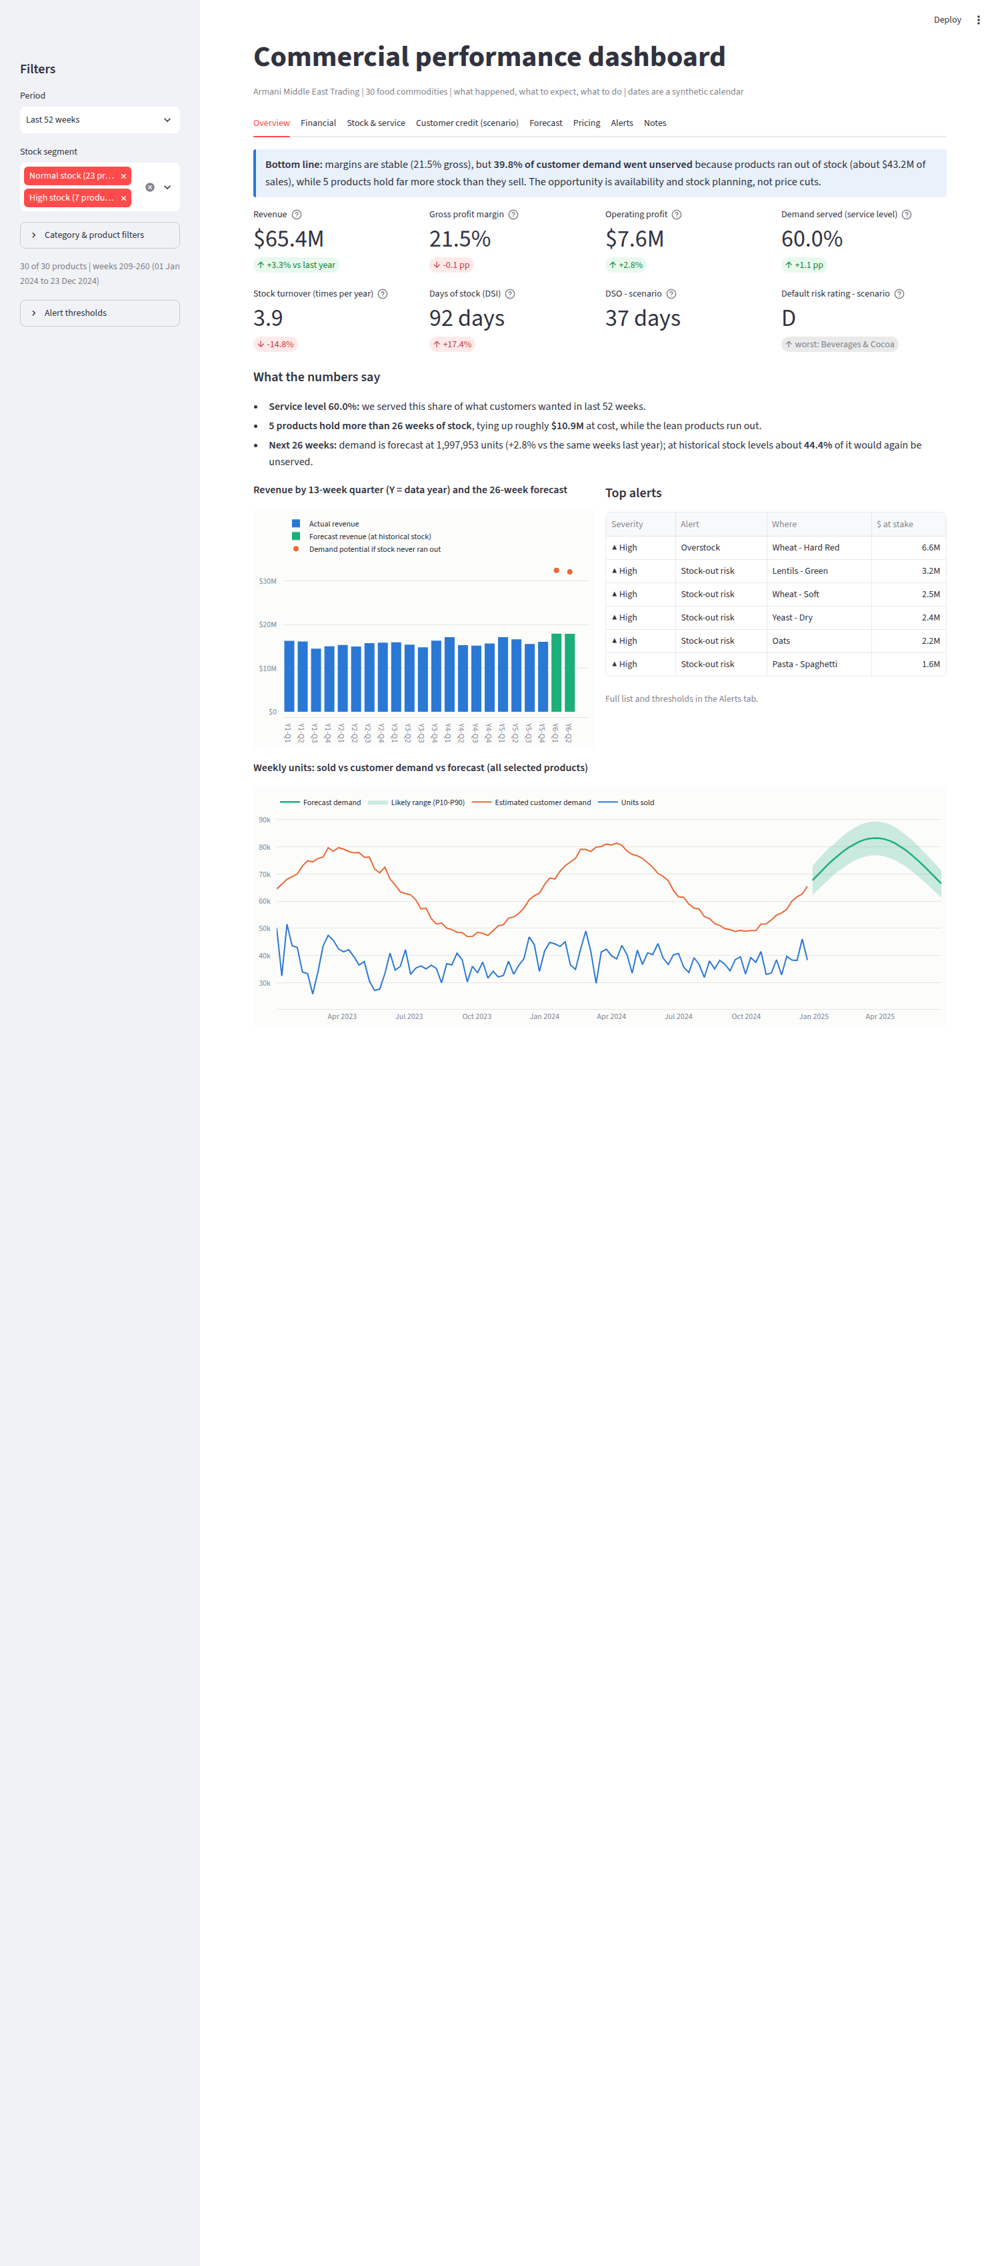

In [9]:
from PIL import Image, ImageChops
from IPython.display import display

for f in sorted(SHOTS.glob(f"dashboard_*.png")):          # crop empty space below the content
    im = Image.open(f).convert("RGB")
    bbox = ImageChops.difference(im, Image.new("RGB", im.size, (255, 255, 255))).getbbox()
    im.crop((0, 0, im.width, min(im.height, bbox[3] + 24))).save(f)
shots = sorted(SHOTS.glob(f"dashboard_*.png"))
print(len(shots), "screenshots:", [s.name for s in shots][:3], "...")
display(Image.open(shots[0]).resize((1000, int(Image.open(shots[0]).height * 1000 / Image.open(shots[0]).width))) if shots else "no screenshots")

## 6. Export to Excel
`dashboard_results.xlsx`: Summary (first sheet), KPIs by category, quarterly trend, credit scenario and default alerts.

In [10]:
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter

A, B = 209, 260                                              # last 52 weeks
cred0 = d["credit_defaults"]
ct0 = app.credit_table(H, A, B, cred0)
rows = []
for cat, g in H.groupby("category"):
    kk = app.kpis(g, A, B); c = ct0.set_index("category").loc[cat]
    rows.append({"category": cat, "products": g.product_id.nunique(), "revenue": kk["revenue"], "growth_vs_last_year": app.growth_yoy(g, A, B), "gross_profit": kk["gross_profit"], "gross_margin": kk["gpm"],
                 "operating_profit": kk["operating_profit"], "operating_margin": kk["opm"], "inventory_turnover": kk["turnover"], "dsi_days": kk["dsi"], "weeks_of_cover": kk["weeks_cover"],
                 "service_level": kk["service_level"], "lost_revenue": kk["lost_revenue"], "dso_days_SCENARIO": c.dso, "risk_rating_SCENARIO": c.rating})
kpi_cat = pd.DataFrame(rows).sort_values("revenue", ascending=False)
rows = []
for pid, g in H.groupby("product_id"):
    kk = app.kpis(g, A, B)
    rows.append({"product": g.product_name.iloc[0], "category": g.category.iloc[0], "segment": g.segment.iloc[0], "revenue": kk["revenue"], "growth_vs_last_year": app.growth_yoy(g, A, B), "gross_margin": kk["gpm"],
                 "operating_margin": kk["opm"], "inventory_turnover": kk["turnover"], "dsi_days": kk["dsi"], "weeks_of_cover": kk["weeks_cover"], "service_level": kk["service_level"], "lost_revenue": kk["lost_revenue"]})
kpi_prod = pd.DataFrame(rows).sort_values("revenue", ascending=False)
qt = H.groupby("pq").agg(revenue=("revenue", "sum"), gross_profit=("gross_profit", "sum"), operating_profit=("operating_profit", "sum"), units=("units", "sum"), demand=("demand_est", "sum"),
                         lost_revenue=("lost_revenue", "sum"), start=("week_start", "min")).reset_index().sort_values("start")
qt["gross_margin"], qt["operating_margin"], qt["service_level"] = qt.gross_profit / qt.revenue, qt.operating_profit / qt.revenue, qt.units / qt.demand
qt["growth_vs_same_quarter_last_year"] = qt.revenue.pct_change(4); qt["start"] = qt.start.dt.strftime("%Y-%m-%d")
FQ = d["fcst"]
fc_q = FQ.groupby("pq").agg(demand_p50=("demand_forecast", "sum"), revenue_potential=("exp_revenue", "sum"), revenue_at_historical_stock=("exp_sales_revenue", "sum"), revenue_at_risk=("exp_lost_revenue", "sum"), gross_profit_potential=("exp_gp", "sum")).reset_index()
fc_c = FQ.groupby("category").agg(demand_p50=("demand_forecast", "sum"), revenue_potential=("exp_revenue", "sum"), revenue_at_historical_stock=("exp_sales_revenue", "sum"), revenue_at_risk=("exp_lost_revenue", "sum")).reset_index().sort_values("revenue_at_risk", ascending=False)
meta = d["meta"]
n_high, n_med = int((al.severity == "High").sum()), int((al.severity == "Medium").sum())
top = al.iloc[0]
ly_dem = H[H.week_id.between(209, 234)].demand_est.sum()
summary = pd.DataFrame([
    ("Financial", "Revenue (last 52 weeks)", f"${k52['revenue']:,.0f}", f"{100 * app.growth_yoy(H, A, B):+.1f}% vs previous 52 weeks"),
    ("Financial", "Gross profit margin", f"{100 * k52['gpm']:.1f}%", "Stable across quarters and categories (21-22%): the lever is volume and stock, not price"),
    ("Financial", "Operating profit / margin", f"${k52['operating_profit']:,.0f} / {100 * k52['opm']:.1f}%", f"Implied operating expenses ${k52['opex']:,.0f}"),
    ("Operational", "Inventory turnover / DSI", f"{k52['turnover']:.1f}x / {k52['dsi']:.0f} days", "Company average hides two worlds: 23 lean products (about 1 week of cover) and 7 over-stocked ones (6 to 370 weeks)"),
    ("Operational", "Service level (fill rate)", f"{100 * k52['service_level']:.0f}%", f"{100 * k52['lost_share']:.0f}% of demand value unserved"),
    ("Operational", "Revenue lost to stock-outs / stock caps (last 52 weeks)", f"${k52['lost_revenue']:,.0f}", "Estimated: reconstructed demand minus sales, at price"),
    ("Sales & credit (SCENARIO)", "DSO (revenue-weighted)", f"{(ct0.dso * ct0.revenue).sum() / ct0.revenue.sum():.0f} days", "Assumption-based: no receivables data exist"),
    ("Sales & credit (SCENARIO)", "Expected credit loss / worst rating", f"${ct0.ecl_annual.sum():,.0f} per year / {ct0.sort_values('risk_score').rating.iloc[-1]} ({ct0.sort_values('risk_score').category.iloc[-1]})", "Assumption-based"),
    ("Forecast", "Demand, next 26 weeks", f"{FQ.demand_forecast.sum():,.0f} units", f"{100 * (FQ.demand_forecast.sum() / ly_dem - 1):+.1f}% vs the same weeks last year; seasonal peak ahead; model: {meta['selected_model']}"),
    ("Forecast", "Revenue potential / at historical stock", f"${FQ.exp_revenue.sum():,.0f} / ${FQ.exp_sales_revenue.sum():,.0f}", f"${FQ.exp_lost_revenue.sum():,.0f} ({100 * FQ.exp_lost_revenue.sum() / FQ.exp_revenue.sum():.0f}%) at risk if stock follows its history"),
    ("Forecast", "Accuracy (WAPE)", f"{100 * float(meta['wape']):.1f}% / {100 * float(meta['wape_truth']):.1f}%", "Reconstructed demand / weeks where demand was observed directly"),
    ("Alerts", "Alerts at default thresholds", f"{len(al)} ({n_high} high, {n_med} medium)", f"Top: {top.severity} {top.type} - {top['name']} (${top.at_stake:,.0f} {top.at_stake_basis})"),
    ("Dashboard", "Tests", f"{int(checks_df.passed.sum())}/{len(checks_df)} passed", "Reconciliation to the ETL database, hand-calculated unit tests, alert-rule checks, app smoke tests"),
], columns=["Area", "KPI", "Value", "Comment"])
summary.insert(0, "#", range(1, len(summary) + 1))
assumptions = pd.DataFrame([
    ("D1", "Synthetic calendar", "Week 1 = Monday 2020-01-06; dates only position weeks in time"),
    ("D2", "Currency", "Not stated in the data; amounts are shown as $"),
    ("D3", "Sales vs demand", "Sales are capped by stock (never above the previous row's inventory); demand is reconstructed in Part 2 preprocessing"),
    ("D4", "Inventory timing", "Inventory used for turnover / DSI / cover is the stock available during each week (previous row's inventory)"),
    ("D5", "Operating expenses", "Not in the data; implied opex = gross profit - operating profit"),
    ("D6", "DSO and default risk", "SCENARIO: payment terms, credit share, payment delay and default rate per category are illustrative assumptions (editable); there are no customers, invoices or receivables in the data"),
    ("D7", "Risk score", "40% default rate (3% = max) + 20% lateness (delay/terms, 50% = max) + 25% expected loss vs gross profit (15% = max) + 15% revenue concentration (25% share = max); ratings A<20, B<35, C<50, D<65, E>=65"),
    ("D8", "Alerts", "Rule-based with adjustable thresholds; '$ at stake' is revenue at risk, capital tied up or expected credit loss depending on the type"),
    ("D9", "Forecast basis", "Revenue at historical stock simulates each product's last-104-week stock availability; revenue potential assumes stock never limits sales"),
    ("D10", "Price effect", "No measurable price effect on demand was found (Part 2), so no price-sensitivity KPI is shown"),
], columns=["#", "Topic", "Assumption"])
shots_list = sorted(SHOTS.glob(f"dashboard_*.png"))
sheets_all = {"Summary": summary, "KPI_Definitions": KPI_DEFS, "KPI_By_Category": kpi_cat.round(4), "KPI_By_Product": kpi_prod.round(4), "Quarterly_Trend": qt.round(4),
          "Forecast_By_Quarter": fc_q.round(1), "Forecast_By_Category": fc_c.round(1), "Alerts_Default": al.round(2), "Credit_Scenario": ct0.round(3), "Credit_Assumptions": cred0,
          "Assumptions": assumptions, "Checks": checks_df}
KEEP = ["Summary", "KPI_By_Category", "Quarterly_Trend", "Credit_Scenario", "Alerts_Default"]
sheets = {k: sheets_all[k] for k in KEEP}
with pd.ExcelWriter(XLSX_PATH, engine="openpyxl") as xw:
    for name, t in sheets.items():
        t.to_excel(xw, sheet_name=name[:31], index=False)
wb = load_workbook(XLSX_PATH)
head_fill = PatternFill("solid", fgColor="1F4E79")
for ws in wb.worksheets:
    for cell in ws[1]:
        cell.font = Font(bold=True, color="FFFFFF"); cell.fill = head_fill; cell.alignment = Alignment(horizontal="center", vertical="center")
    ws.freeze_panes = "A2"
    for i, col in enumerate(ws.columns, 1):
        width = max(len(str(c.value)) if c.value is not None else 0 for c in list(col)[:300])
        ws.column_dimensions[get_column_letter(i)].width = min(max(width + 2, 8), 70)
for name, widths in {"Summary": [5, 24, 48, 36, 100]}.items():
    for col, w in zip("ABCDE", widths):
        wb[name].column_dimensions[col].width = w
    for r in wb[name].iter_rows(min_row=2):
        for c in r: c.alignment = Alignment(wrap_text=True, vertical="top")
wb.save(XLSX_PATH)
print("Saved:", XLSX_PATH.name, "| sheets:", wb.sheetnames)
summary

Saved: dashboard_results.xlsx | sheets: ['Summary', 'KPI_By_Category', 'Quarterly_Trend', 'Credit_Scenario', 'Alerts_Default']


,#,Area,KPI,Value,Comment
0,1,Financial,Revenue (last 52 weeks),"$65,353,105",+3.3% vs previous 52 weeks
1,2,Financial,Gross profit margin,21.5%,Stable across quarters and categories (21-22%)...
2,3,Financial,Operating profit / margin,"$7,627,830 / 11.7%","Implied operating expenses $6,409,557"
3,4,Operational,Inventory turnover / DSI,3.9x / 92 days,Company average hides two worlds: 23 lean prod...
4,5,Operational,Service level (fill rate),60%,40% of demand value unserved
5,6,Operational,Revenue lost to stock-outs / stock caps (last ...,"$43,168,199","Estimated: reconstructed demand minus sales, a..."
6,7,Sales & credit (SCENARIO),DSO (revenue-weighted),37 days,Assumption-based: no receivables data exist
7,8,Sales & credit (SCENARIO),Expected credit loss / worst rating,"$524,966 per year / D (Beverages & Cocoa)",Assumption-based
8,9,Forecast,"Demand, next 26 weeks","1,997,953 units",+2.8% vs the same weeks last year; seasonal pe...
9,10,Forecast,Revenue potential / at historical stock,"$64,552,904 / $35,812,622","$28,681,182 (44%) at risk if stock follows its..."


## 7. Outputs
| File | Purpose |
|---|---|
| `part3_dashboard/dashboard_app.py` | the Streamlit app (committed) |
| `part3_dashboard/dashboard_data.db` | data mart read by the app (committed; Part 4 adds the pricing tables) |
| `part3_dashboard/requirements.txt`, `RUN_DASHBOARD.md` | dependencies and run / deployment instructions |
| `results/part3_dashboard/dashboard_results.xlsx`, `screenshots/` | results workbook, one screenshot per tab |

Run locally: `streamlit run part3_dashboard/dashboard_app.py`.